<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 1 - Import Library dan Penetapan Random Seed
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
">Tahap awal tentunya kita import semua library yang kita gunakan. Disini kita bakal pake tensorflow/keras untuk build modelnya, scikit-learn untuk evaluasi dan split dataset. Kalo di notebook sebelumnya, kita juga pake cv2 Preprocessing citra (resize, hair removal) sama matplotlib untuk visualisasi. Penetapan SEED itu gunanya agar setiap kali hasil eksperimen bisa diulang mendaptakan hasil yang sama.
</p> 

</div>

In [1]:
#Setup & Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import gc
import time
import cv2

#TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop

#Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score,f1_score)
from sklearn.utils.class_weight import compute_class_weight

print("import selesai")

2026-06-05 05:45:43.362189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780638343.582562      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780638343.641055      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780638344.150442      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780638344.150494      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780638344.150497      22 computation_placer.cc:177] computation placer alr

import selesai


In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed: {SEED}")

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

Random seed: 42
TensorFlow version: 2.19.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 2 - Konfigurasi Hyperparameter dan Load Data
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
"> Kita define dan print hyperparameter yang kita gunakan, dan juga load data preprocesing dari hasil notebook sebelumnya
</p> 

</div>

In [3]:
print("Path Data dan Hyperparameter")
print("=" * 50)

PATH_DATA = '/kaggle/input/notebooks/vaniaangelica/preprosessing'

# Hyperparameter
IMG_SIZE       = 224    
NUM_CLASSES    = 3      
BATCH_SIZE     = 32     
EPOCHS         = 50     
LEARNING_RATE  = 1e-4   
N_FOLDS        = 5      

print(f"Image Size    = {IMG_SIZE}")
print(f"Jumlah Kelas  = {NUM_CLASSES}")
print(f"Batch Size    = {BATCH_SIZE}")
print(f"Epoch         = {EPOCHS}")
print(f"Learning Rate = {LEARNING_RATE}")
print(f"Jumlah Fold   = {N_FOLDS}")

Path Data dan Hyperparameter
Image Size    = 224
Jumlah Kelas  = 3
Batch Size    = 32
Epoch         = 50
Learning Rate = 0.0001
Jumlah Fold   = 5


In [4]:
print("Load Data Preprocessing")
print("=" * 50)

path_X = os.path.join(PATH_DATA, 'X_preprocessed.npy')
path_y = os.path.join(PATH_DATA, 'y_labels.npy')
X = np.load(path_X)
y_labels = np.load(path_y)

print(f"Shape X (gambar) : {X.shape}")
print(f"Shape y (label)  : {y_labels.shape}")
print(f"Tipe data X      : {X.dtype}")
print(f"Range pixel      : [{X.min()}, {X.max()}]")
print(" ")

#Tampilan jumlah per kelas
print(f"Distribusi kelas:")
for kelas in ['MEL', 'BCC', 'SCC']:
    jumlah = np.sum(y_labels == kelas)
    print(f"{kelas}: {jumlah} gambar")

Load Data Preprocessing
Shape X (gambar) : (8458, 224, 224, 3)
Shape y (label)  : (8458,)
Tipe data X      : uint8
Range pixel      : [0, 255]
 
Distribusi kelas:
MEL: 4514 gambar
BCC: 3316 gambar
SCC: 628 gambar


<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 3 - Encode Label dan Undersampling
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
"> Disini kita bakal lihat contoh persebaran pixel terus juga encode label pakai one-hot-encode 
    dan karena kelas kita imbalanced kita undersampling kelas melanoma dan bcc.
</p> 

</div>

In [5]:
"""
Encode dilakukan untuk mengubah label kelas string menjadi bentuk numerik.
Di sini kita lebih memakai one-hot encoding, dimana 
numerik yang terbentuk mirip seperti kolom biner.

Namun pengubahan menjadi one-hot encoding akan dilakukan dalam loop training. 
Pada cell ini one-hot encoding yang di keluarkan sebagai contoh saja,
karena y_encode yang disini akan di overide pada bagian undersampling nanti. 
"""

LabelEncode = LabelEncoder()
y_encoded = LabelEncode.fit_transform(y_labels) 

print("Mapping Label:")
print(" ")
for i, nama_kelas in enumerate(LabelEncode.classes_):
    jumlah = np.sum(y_encoded == i)
    print(f"{nama_kelas} : {i} ({jumlah} gambar)")

# One-Hot Encoding
y_onehot = to_categorical(y_encoded, num_classes=NUM_CLASSES)

print(f"Shape y_encoded : {y_encoded.shape}")
print(f"Shape y_onehot  : {y_onehot.shape}")

print(" ")
print(f"Contoh encoding (3 gambar pertama):")
for i in range(3):
    print(f"    '{y_labels[i]}' → {y_encoded[i]} → {y_onehot[i]}")

Mapping Label:
 
BCC : 0 (3316 gambar)
MEL : 1 (4514 gambar)
SCC : 2 (628 gambar)
Shape y_encoded : (8458,)
Shape y_onehot  : (8458, 3)
 
Contoh encoding (3 gambar pertama):
    'MEL' → 1 → [0. 1. 0.]
    'MEL' → 1 → [0. 1. 0.]
    'MEL' → 1 → [0. 1. 0.]


RANDOM UNDERSAMPLING
 
Distribusi Sebelum Undersampling:
BCC: 3316 gambar
MEL: 4514 gambar
SCC: 628 gambar
 
Distribusi Sesudah Undersampling:
BCC (0): 2000 gambar
MEL (1): 2000 gambar
SCC (2): 628 gambar
Total : 4628 gambar


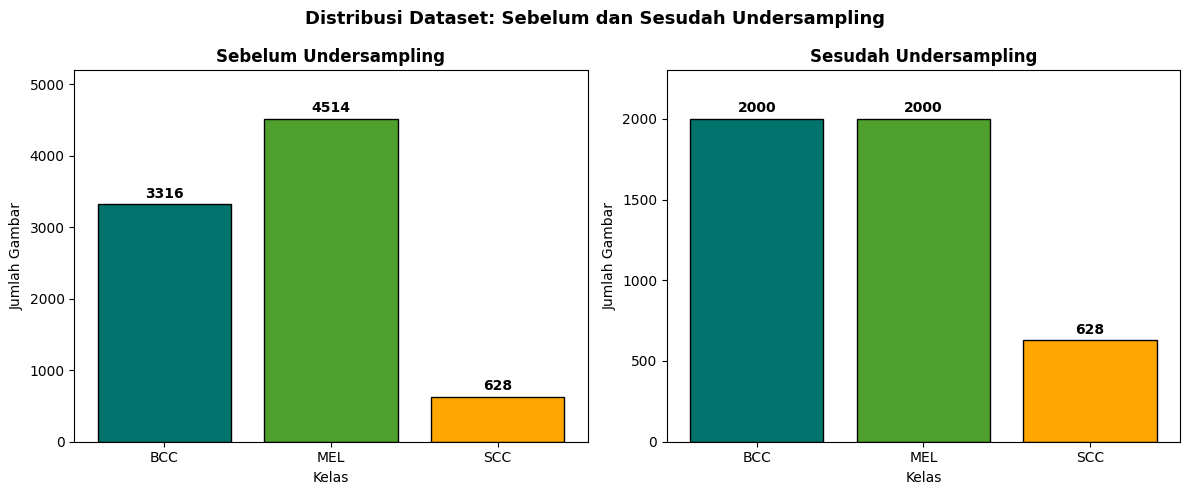


Variabel X, y_encoded, y_labels yang sudah di replace.
Shape X baru    : (4628, 224, 224, 3)
Shape y baru    : (4628,)


In [6]:
print("RANDOM UNDERSAMPLING")
print("=" * 50)

# Distribusi sebelum undersampling 
print(" ")
print("Distribusi Sebelum Undersampling:")
y_labels_asli  = np.load(os.path.join(PATH_DATA, 'y_labels.npy'))
y_encoded_asli = LabelEncode.transform(y_labels_asli)

jumlah_per_kelas_awal = []
for i, nama in enumerate(LabelEncode.classes_):
    jumlah = int(np.sum(y_encoded_asli == i))
    jumlah_per_kelas_awal.append(jumlah)
    print(f"{nama}: {jumlah} gambar")

#Target jumlah kelas 
target_per_kelas = {
    0: 2000,  
    1: 2000,  
    2: 628    
}

#Random undersample setiap kelas
np.random.seed(SEED)

idx_under = []
for i in range(NUM_CLASSES):
    idx_kelas = np.where(y_encoded == i)[0]
    target    = target_per_kelas[i]

    if len(idx_kelas) <= target:
        idx_dipilih = idx_kelas #semua kelas SCC diambil
    else:
        idx_dipilih = np.random.choice(idx_kelas, size=target, replace=False)

    idx_under.extend(idx_dipilih.tolist())

# Shuffle agar urutan kelas tidak berurutan
idx_under = np.array(idx_under)
np.random.shuffle(idx_under)

#Buat array baru
X_under       = X[idx_under]           # gambar hasil undersample
y_under       = y_encoded[idx_under]   # label integer
y_labels_under = y_labels[idx_under]   # label teks (MEL/BCC/SCC)

#Distribusi Sesudah Undersampling
print(" ")
print("Distribusi Sesudah Undersampling:")
jumlah_per_kelas_akhir = []
for i, nama in enumerate(LabelEncode.classes_):
    jumlah = int(np.sum(y_under == i))
    jumlah_per_kelas_akhir.append(jumlah)
    print(f"{nama} ({i}): {jumlah} gambar")
print(f"Total : {len(y_under)} gambar")

#Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Dataset: Sebelum dan Sesudah Undersampling',fontsize=13, fontweight='bold')

nama_kelas_list = list(LabelEncode.classes_)
warna = ['#00746c', '#4f9f2c', '#ffa600']

# Sebelum undersampling
axes[0].bar(nama_kelas_list, jumlah_per_kelas_awal, color=warna, edgecolor='black')
axes[0].set_title('Sebelum Undersampling', fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, max(jumlah_per_kelas_awal) * 1.15)
for i, v in enumerate(jumlah_per_kelas_awal):
    axes[0].text(i, v + max(jumlah_per_kelas_awal) * 0.02, str(v),ha='center', fontweight='bold')

# Sesudah undersampling
axes[1].bar(nama_kelas_list, jumlah_per_kelas_akhir, color=warna, edgecolor='black')
axes[1].set_title('Sesudah Undersampling', fontweight='bold')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_ylim(0, max(jumlah_per_kelas_akhir) * 1.15)
for i, v in enumerate(jumlah_per_kelas_akhir):
    axes[1].text(i, v + max(jumlah_per_kelas_akhir) * 0.02, str(v),ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#Override variabel utama 
X         = X_under
y_encoded = y_under
y_labels  = y_labels_under

print("\nVariabel X, y_encoded, y_labels yang sudah di replace.")
print(f"Shape X baru    : {X.shape}")
print(f"Shape y baru    : {y_encoded.shape}")

<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 4 - Augmentasi Citra
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
"> Kita define dan print hyperparameter yang kita gunakan, dan juga load data preprocesing dari hasil notebook sebelumnya
</p> 

</div>

In [7]:
#Tujuan augmentasi data ini untuk variasi data
#saat masuk ke loop training 
print("Augmentasi hanya untuk data training")
print("Data validasi tidak di augmentasi")

#Augmentasi untuk data TRAINING
train_datagen = ImageDataGenerator(
    rotation_range=180,           # Rotasi acak 0-180 derajat
    width_shift_range=0.1,        # Geser horizontal 10%
    height_shift_range=0.1,       # Geser vertikal 10%
    zoom_range=0.1,               # Zoom in/out 10%
    horizontal_flip=True,         # Flip horizontal
    vertical_flip=True,           # Flip vertikal
    fill_mode='nearest'           # Isi piksel kosong dengan piksel terdekat
)

# Untuk data validasi, tanpa augmentasi (data asli saja)
val_datagen = ImageDataGenerator()

Augmentasi hanya untuk data training
Data validasi tidak di augmentasi


Contoh Augmentasi


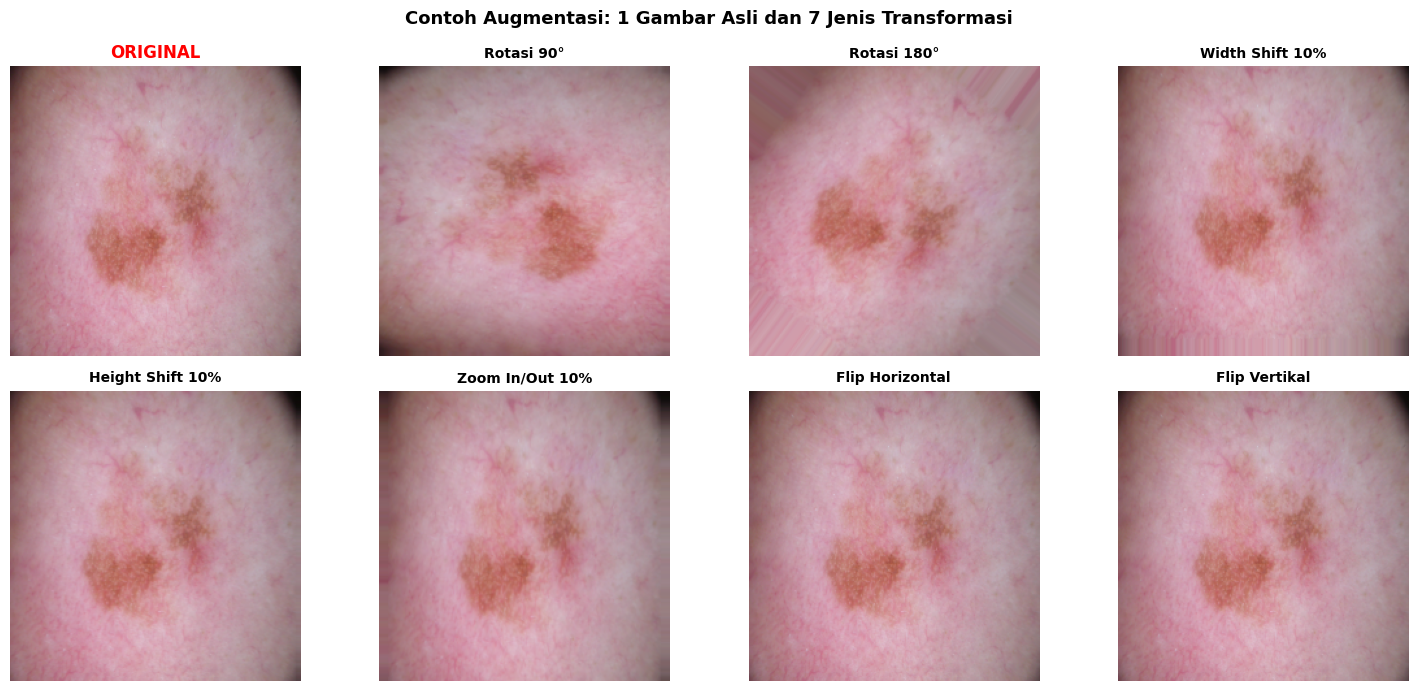

In [8]:
print("Contoh Augmentasi")
print("=" * 50)

#disini kita laukakan augmentasi on-the=fly
gambar_contoh = X[0:1] 

daftar_augmentasi = [
    ('Rotasi 90°',        ImageDataGenerator(rotation_range=90)),
    ('Rotasi 180°',       ImageDataGenerator(rotation_range=180)),
    ('Width Shift 10%',   ImageDataGenerator(width_shift_range=0.1)),
    ('Height Shift 10%',  ImageDataGenerator(height_shift_range=0.1)),
    ('Zoom In/Out 10%',   ImageDataGenerator(zoom_range=0.1)),
    ('Flip Horizontal',   ImageDataGenerator(horizontal_flip=True)),
    ('Flip Vertikal',     ImageDataGenerator(vertical_flip=True)),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle('Contoh Augmentasi: 1 Gambar Asli dan 7 Jenis Transformasi',
             fontsize=13, fontweight='bold')

# Gambar asli
axes[0, 0].imshow(gambar_contoh[0])
axes[0, 0].set_title('ORIGINAL', fontweight='bold', color='red')
axes[0, 0].axis('off')

# 7 jenis augmentasi
for i, (nama_aug, datagen) in enumerate(daftar_augmentasi):
    baris = (i + 1) // 4
    kolom = (i + 1) % 4
    aug_iter = datagen.flow(gambar_contoh, batch_size=1)
    
    #Ambil gambar augmentasi
    gambar_aug = next(aug_iter)[0]
    
    #Cast float32 [0, 255] kembali ke uint8
    gambar_aug_tampil = gambar_aug.astype('uint8')
    
    axes[baris, kolom].imshow(gambar_aug_tampil)
    axes[baris, kolom].set_title(nama_aug, fontsize=10, fontweight='bold')
    axes[baris, kolom].axis('off')

plt.tight_layout()
plt.show()

<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 5 - Rancangan Model 
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
"> Selanjutnya kita akan menampilkan model yang akan kita gunakan dan dijelaskan dalam bentuk model demo. Disini kita juga membuat fungsi untuk memilih optimizer dan setup stratified k-fold.</p> 

</div>

In [9]:
print("Arsitektur Model")
print("=" * 50)

def buat_model():
    
    #Kita load base model pretraid dan buang classification head bawaan
    #Buang head = "include_top=False"
    #Backbone tidak di train = "base_model.trainable = False"
    base_model = EfficientNetB2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    #Pakai pakai input/output milik base_model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

#Menampilkan arsitektur
model_demo = buat_model()
model_demo.summary()

#Verifikasi nama layer Conv2D terakhir untuk GradCAM
print("\nVerifikasi target layer GradCAM:")
for layer in reversed(model_demo.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        GRADCAM_LAYER = layer.name
        print(f"Conv2D terakhir : '{GRADCAM_LAYER}'")
        print(f"Output shape    : {layer.output.shape}")
        break
        
print(" ")
print(f"GradCam Layer : '{GRADCAM_LAYER}'")

#Hitung jumlah parameter
total_params     = model_demo.count_params()
trainable_params = sum([tf.keras.backend.count_params(w)
                        for w in model_demo.trainable_weights])
frozen_params    = total_params - trainable_params

print(f"\nTotal parameter   : {total_params:,}")
print(f"Parameter dilatih : {trainable_params:,}")
print(f"Parameter frozen  : {frozen_params:,}")

#hapus model demo biar memori ngga penuh
del model_demo
gc.collect()
tf.keras.backend.clear_session()

Arsitektur Model


I0000 00:00:1780638369.215233      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 8,130,044 (31.01 MB)

 Trainable params: 361,475 (1.38 MB)

 Non-trainable params: 7,768,569 (29.63 MB)


Verifikasi target layer GradCAM:
Conv2D terakhir : 'top_conv'
Output shape    : (None, 7, 7, 1408)
 
GradCam Layer : 'top_conv'

Total parameter   : 8,130,044
Parameter dilatih : 361,475
Parameter frozen  : 7,768,569


In [10]:
print("Optimizer")
print("=" * 50)

def pilih_optimizer(nama_optimizer):
    if nama_optimizer == 'Adam':
        return Adam(learning_rate=LEARNING_RATE)
    elif nama_optimizer == 'RMSprop':
        return RMSprop(learning_rate=LEARNING_RATE)
    else: 
        raise ValueError(f"Optimizer '{nama_optimizer}' tidak dikenal. "
                         f"Pilih: 'Adam' atau 'RMSprop'")

# Daftar optimizer yang akan dibandingkan
daftar_optimizer = ['Adam', 'RMSprop']
print(f"Optimizer yang akan dibandingkan: {daftar_optimizer}")

Optimizer
Optimizer yang akan dibandingkan: ['Adam', 'RMSprop']


In [11]:
print("Focal Loss")
print("=" * 50)

# Alpha otomatis proporsional dengan distribusi 2000:2000:628
bobot_kelas_raw = compute_class_weight(
    'balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

#pake Alpha apa adanya
bobot_kelas = bobot_kelas_raw.tolist()

focal_loss_function = tf.keras.losses.CategoricalFocalCrossentropy(
    alpha=bobot_kelas,
    gamma=2.0
)

print("Alpha per kelas:")
for i, nama in enumerate(LabelEncode.classes_):
    print(f"{nama}: {bobot_kelas_raw[i]:.4f}")
print(f"\nGamma : 2.0")

Focal Loss
Alpha per kelas:
BCC: 0.7713
MEL: 0.7713
SCC: 2.4565

Gamma : 2.0


In [12]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(X, y_encoded))

print(f"Stratified {N_FOLDS}-Fold Validation")
print("=" * 55)
print(f"Total data: {len(y_encoded)} gambar, dibagi {N_FOLDS} fold")
print( )

# Tampilkan isi tiap fold
for fold in range(N_FOLDS):
    _, idx_val = splits[fold]
    y_val = y_encoded[idx_val]
    detail = ", ".join(
        f"{LabelEncode.classes_[i]}={np.sum(y_val==i)}"
        for i in range(NUM_CLASSES)
    )
    print(f"  Fold {fold+1}: {len(idx_val)} gambar  [{detail}]")


print("-" * 55 )
# Tampilkan tiap iterasi training
for fold, (idx_train, idx_val) in enumerate(splits):
    y_train_fold = y_encoded[idx_train]
    y_val_fold   = y_encoded[idx_val]

    fold_training = "+".join(f"Fold {j+1}" for j in range(N_FOLDS) if j != fold)
    detail_val   = ", ".join(
        f"{LabelEncode.classes_[i]}={np.sum(y_val_fold==i)}"
        for i in range(NUM_CLASSES)
    )
    detail_train = ", ".join(
        f"{LabelEncode.classes_[i]}={np.sum(y_train_fold==i)}"
        for i in range(NUM_CLASSES)
    )

    print(f"Iterasi {fold+1}: [Fold {fold+1} = VALIDASI]  [{fold_training} = TRAINING]")
    print(f"  Validasi : {len(idx_val):4d} gambar  [{detail_val}]")
    print(f"  Training : {len(idx_train):4d} gambar  [{detail_train}]")
    print()

Stratified 5-Fold Validation
Total data: 4628 gambar, dibagi 5 fold

  Fold 1: 926 gambar  [BCC=400, MEL=400, SCC=126]
  Fold 2: 926 gambar  [BCC=400, MEL=400, SCC=126]
  Fold 3: 926 gambar  [BCC=400, MEL=400, SCC=126]
  Fold 4: 925 gambar  [BCC=400, MEL=400, SCC=125]
  Fold 5: 925 gambar  [BCC=400, MEL=400, SCC=125]
-------------------------------------------------------
Iterasi 1: [Fold 1 = VALIDASI]  [Fold 2+Fold 3+Fold 4+Fold 5 = TRAINING]
  Validasi :  926 gambar  [BCC=400, MEL=400, SCC=126]
  Training : 3702 gambar  [BCC=1600, MEL=1600, SCC=502]

Iterasi 2: [Fold 2 = VALIDASI]  [Fold 1+Fold 3+Fold 4+Fold 5 = TRAINING]
  Validasi :  926 gambar  [BCC=400, MEL=400, SCC=126]
  Training : 3702 gambar  [BCC=1600, MEL=1600, SCC=502]

Iterasi 3: [Fold 3 = VALIDASI]  [Fold 1+Fold 2+Fold 4+Fold 5 = TRAINING]
  Validasi :  926 gambar  [BCC=400, MEL=400, SCC=126]
  Training : 3702 gambar  [BCC=1600, MEL=1600, SCC=502]

Iterasi 4: [Fold 4 = VALIDASI]  [Fold 1+Fold 2+Fold 3+Fold 5 = TRAINING]


<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 6 - Training Model 
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
"> Setelah semua sudah di define, sekarang  kita akan melakukan training model.</p> 

</div>

In [13]:
print("Membuat KFoldDataGenerator")
print("=" * 50)

from tensorflow.keras.utils import Sequence
import math

class KFoldDataGenerator(Sequence):
    
    """
    Custom Data Generator untuk Stratified K-Fold.
    Mengambil data per-batch (~18 MB) dari X uint8 langsung,
    tanpa menyalin seluruh data training ke memori.

    Alur per-batch:
      X uint8 - float32 - augmentasi - preprocess_input - [-1, 1]
    
    Parameter:
        X_sumber   : array gambar utama, X uint8 asli
        y_sumber   : array label one-hot untuk seluruh data
        indices    : daftar indeks gambar untuk fold ini
        batch_size : jumlah gambar per batch
        datagen    : ImageDataGenerator untuk augmentasi (None = tanpa augmentasi)
        shuffle    : acak urutan data setiap epoch
    """
    
    def __init__(self, X_sumber, y_sumber, indices, 
                 batch_size, datagen=None, shuffle=True):
        self.X_sumber = X_sumber
        self.y_sumber = y_sumber
        self.indices = indices.copy()
        self.batch_size = batch_size
        self.datagen = datagen
        self.shuffle = shuffle
        self.on_epoch_end()
        
    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)
        
    def __getitem__(self, idx):
        # Ambil indeks untuk batch ini
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        # Ambil batch & konversi ke float32
        # .astype() membuat array baru (tidak modifikasi X asli)
        batch_x = self.X_sumber[batch_idx].astype(np.float32)  # [0, 255] float32
        batch_y = self.y_sumber[batch_idx]
        
       # Pertama, Augmentasi dulu untuk training
        # datagen.flow() lebih cepat dari loop random_transform satu-per-satu
        if self.datagen is not None:
            batch_x = next(
                self.datagen.flow(batch_x,
                                  batch_size=len(batch_x),
                                  shuffle=False)   # shuffle=False, urutan sudah diatur
            )
        
        # Kedua, normalisasi setelah augmentasi
        # preprocess_input: [0, 255] → [-1, 1]  
        batch_x = preprocess_input(batch_x)
                
        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print("KFoldDataGenerator siap!")

Membuat KFoldDataGenerator
KFoldDataGenerator siap!


In [14]:
print("Training Model")
print("=" * 50)

hasil = {}
for nama_opt in daftar_optimizer:
    hasil[nama_opt] = {
        'history'      : [],   # History training per fold
        'val_acc'      : [],   # Best val accuracy per fold
        'val_macro_f1' : [],   # Macro F1 per fold
        'y_true'       : [],   # Label asli (dari semua fold, digabung)
        'y_pred'       : [],   # Label prediksi (dari semua fold, digabung)
        'y_true_fold'  : [],   
        'y_pred_fold'  : [],   
    }

# Variabel untuk menyimpan model terbaik secara keseluruhan
best_acc_per_optimizer   = {nama: 0.0 for nama in daftar_optimizer}  
best_model_info_per_opt  = {}              

#One-Hot Encoding untuk seluruh data (dipakai oleh generator)
y_encoded_oh = to_categorical(y_encoded, NUM_CLASSES)

waktu_mulai_total = time.time()

# LOOP TRAINING UTAMA 
for nama_opt in daftar_optimizer:

    print(f"\n{'—'*55}")
    print(f"OPTIMIZER: {nama_opt}")
    print(f"{'—'*55}")

    waktu_mulai_opt = time.time()

    for fold, (idx_train, idx_val) in enumerate(skf.split(X, y_encoded)):

        tf.keras.backend.clear_session()
        gc.collect()

        print(f"\n  --- Fold {fold+1}/{N_FOLDS} ({nama_opt}) ---")

        # 1. kita ambil label untuk menampilkan distribusi
        y_train = y_encoded[idx_train]

        # Menampilkan kelas di fold yang sedang berjalan
        print(f"  Distribusi Training:")
        for kls in np.unique(y_train):
            print(f"    {LabelEncode.classes_[kls]}: {np.sum(y_train == kls)}")
        print(f"  Total Training: {len(y_train)} | Validation: {len(idx_val)}")

        # 2. Buat Generator Training
        train_generator = KFoldDataGenerator(
            X_sumber=X,
            y_sumber=y_encoded_oh,
            indices=idx_train,
            batch_size=BATCH_SIZE,
            datagen=train_datagen,
            shuffle=True
        )

        # 3. Siapkan data validasi
        val_generator = KFoldDataGenerator(
            X_sumber=X,
            y_sumber=y_encoded_oh,
            indices=idx_val,
            batch_size=BATCH_SIZE,
            datagen=None,      # valiadsi tanpa augmentasi
            shuffle=False      # validasi tidak perlu di-shuffle
        )
        
        # 4. Buat model baru
        model = buat_model()

        # 5. Compile model dengan focal loss
        optimizer = pilih_optimizer(nama_opt)
        model.compile(
            optimizer=optimizer,
            loss= focal_loss_function,
            metrics=['accuracy']
        )

        # 6. Callbacks 
        # Early Stopping
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            min_delta=1e-4,  
            restore_best_weights=True,
            verbose=1
        )

        # ReduceLROnPlateau
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_delta=1e-4, 
            min_lr=1e-6,
            verbose=1
        )

        # 7. Training Dataset
        # Disini generator memberikan data per-batch dengan augmentasi on-the-fly
        print(f"Mulai training...")
        history = model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=EPOCHS,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

        # 8. Evaluasi pada validation set
        y_pred_proba = model.predict(val_generator, verbose=0)
        y_pred       = np.argmax(y_pred_proba, axis=1)
        y_val_true   = np.argmax(y_encoded_oh[idx_val], axis=1)
        val_acc      = accuracy_score(y_val_true, y_pred)
        val_macro_f1 = f1_score(y_val_true, y_pred, average='macro')

        print(f" Fold {fold+1} selesai!")
        print(f"  Val Accuracy : {val_acc:.4f}")
        print(f"  Val Macro F1 : {val_macro_f1:.4f}")

        # 9. Simpan hasil
        hasil[nama_opt]['history'].append(history.history)
        hasil[nama_opt]['val_acc'].append(val_acc)
        hasil[nama_opt]['val_macro_f1'].append(val_macro_f1)
        hasil[nama_opt]['y_true'].extend(y_val_true.tolist())
        hasil[nama_opt]['y_pred'].extend(y_pred.tolist())
        hasil[nama_opt]['y_true_fold'].append(list(y_val_true))
        hasil[nama_opt]['y_pred_fold'].append(list(y_pred))

        # 10. Cek apakah ini model terbaik secara keseluruhan
        if val_acc > best_acc_per_optimizer[nama_opt]:
            best_acc_per_optimizer[nama_opt] = val_acc
            best_model_info_per_opt[nama_opt] = {
                'optimizer'    : nama_opt,
                'fold'         : fold + 1,
                'val_acc'      : val_acc,
                'val_macro_f1' : val_macro_f1,
            }
    
            # Simpan model terbaik
            model.save(f'/kaggle/working/model_terbaik_efficientnet_partial_LR2{nama_opt}.keras')
            print(f">>> Model Terbaik Baru untuk {nama_opt} (Accuracy={val_acc:.4f}) <<<")

        # 11. Incremental Saving 
        np.save('/kaggle/working/hasil_backup_efficientnet_partial_LR2.npy', {
            'hasil': hasil, 
            'best_acc_per_optimizer': best_acc_per_optimizer,  
            'best_model_info_per_opt': best_model_info_per_opt, 
            'fold_terakhir': f"{nama_opt}_fold{fold+1}"
        })
        
        print(f"Backup disimpan! (progress aman sampai {nama_opt} Fold {fold+1})")

        # 12. Bersihkan memori setelah setiap fold
        del train_generator, val_generator         
        del y_train, y_val_true, y_pred_proba, y_pred
        del model
        gc.collect()
        tf.keras.backend.clear_session()

    waktu_opt = (time.time() - waktu_mulai_opt) / 60
    rata_acc = np.mean(hasil[nama_opt]['val_acc'])
    rata_f1  = np.mean(hasil[nama_opt]['val_macro_f1'])
    print(f"\n  {nama_opt} selesai! Rata-rata Acc: {rata_acc:.4f} | Macro F1: {rata_f1:.4f} ({waktu_opt:.1f} menit)")

#Menentukan optimizer terbaik berdasarkan rata-rata macro F1-Score
rata_acc_per_opt = {nama: np.mean(hasil[nama]['val_acc']) for nama in daftar_optimizer}
opt_terbaik = max(rata_acc_per_opt, key=rata_acc_per_opt.get)

print(f"\nOptimizer terbaik (rata-rata Accuracy): {opt_terbaik} ({rata_acc_per_opt[opt_terbaik]:.4f})")
print(f"Model tersimpan di: /kaggle/working/model_terbaik_efficientnet_partial_LR2{opt_terbaik}.keras")

waktu_total = (time.time() - waktu_mulai_total) / 60
info_opt = best_model_info_per_opt[opt_terbaik]
print(f"\n{'—'*55}")
print(f"  Training Sudah Selesai, dengan total waktu: {waktu_total:.1f} menit")
print(f"  Optimizer terbaik : {opt_terbaik} (rata-rata Accuracy: {rata_acc_per_opt[opt_terbaik]:.4f})")
print(f"  Fold terbaik      : Fold {info_opt['fold']}")
print(f"  Macro F1 (fold)   : {info_opt['val_macro_f1']:.4f}")
print(f"  Val Accuracy      : {info_opt['val_acc']:.4f}")
print(f"{'—'*55}")

Training Model

———————————————————————————————————————————————————————
OPTIMIZER: Adam
———————————————————————————————————————————————————————

  --- Fold 1/5 (Adam) ---
  Distribusi Training:
    BCC: 1600
    MEL: 1600
    SCC: 502
  Total Training: 3702 | Validation: 926
Mulai training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1780638393.775396      70 service.cc:152] XLA service 0x7ee1900022f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780638393.775440      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780638397.428690      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780638416.557154      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/116 ━━━━━━━━━━━━━━━━━━━━ 124s 726ms/step - accuracy: 0.4679 - loss: 0.5089 - val_accuracy: 0.6026 - val_loss: 0.3479 - learning_rate: 1.0000e-04
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 44s 377ms/step - accuracy: 0.6113 - loss: 0.3664 - val_accuracy: 0.6274 - val_loss: 0.3159 - learning_rate: 1.0000e-04
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 364ms/step - accuracy: 0.6367 - loss: 0.3382 - val_accuracy: 0.6631 - val_loss: 0.3022 - learning_rate: 1.0000e-04
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 365ms/step - accuracy: 0.6561 - loss: 0.3179 - val_accuracy: 0.6533 - val_loss: 0.2951 - learning_rate: 1.0000e-04
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 365ms/step - accuracy: 0.6704 - loss: 0.3027 - val_accuracy: 0.7041 - val_loss: 0.2806 - learning_rate: 1.0000e-04
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 373ms/step - accuracy: 0.6845 - loss: 0.2988 - val_accuracy: 0.6976 - val_loss: 0.2777 - learning_rate: 1.0000e-04
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 369ms/step -

...

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 113s 680ms/step - accuracy: 0.5016 - loss: 0.4748 - val_accuracy: 0.6242 - val_loss: 0.3624 - learning_rate: 1.0000e-04
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 370ms/step - accuracy: 0.6051 - loss: 0.3723 - val_accuracy: 0.6782 - val_loss: 0.3321 - learning_rate: 1.0000e-04
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 368ms/step - accuracy: 0.6361 - loss: 0.3417 - val_accuracy: 0.6901 - val_loss: 0.3133 - learning_rate: 1.0000e-04
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 360ms/step - accuracy: 0.6629 - loss: 0.3219 - val_accuracy: 0.6911 - val_loss: 0.3054 - learning_rate: 1.0000e-04
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 367ms/step - accuracy: 0.6823 - loss: 0.3045 - val_accuracy: 0.6987 - val_loss: 0.2990 - learning_rate: 1.0000e-04
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 370ms/step - accuracy: 0.6961 - loss: 0.2930 - val_accuracy: 0.6911 - val_loss: 0.2900 - learning_rate: 1.0000e-04
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 3

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 108s 644ms/step - accuracy: 0.5018 - loss: 0.4861 - val_accuracy: 0.5849 - val_loss: 0.3635 - learning_rate: 1.0000e-04
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 43s 366ms/step - accuracy: 0.6022 - loss: 0.3770 - val_accuracy: 0.6573 - val_loss: 0.3321 - learning_rate: 1.0000e-04
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 353ms/step - accuracy: 0.6416 - loss: 0.3354 - val_accuracy: 0.6703 - val_loss: 0.3131 - learning_rate: 1.0000e-04
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - accuracy: 0.6724 - loss: 0.3124 - val_accuracy: 0.6692 - val_loss: 0.3007 - learning_rate: 1.0000e-04
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 359ms/step - accuracy: 0.6830 - loss: 0.3031 - val_accuracy: 0.6714 - val_loss: 0.2957 - learning_rate: 1.0000e-04
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 353ms/step - accuracy: 0.6867 - loss: 0.2970 - val_accuracy: 0.6908 - val_loss: 0.2900 - learning_rate: 1.0000e-04
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 3

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 107s 648ms/step - accuracy: 0.5107 - loss: 0.4663 - val_accuracy: 0.6778 - val_loss: 0.3377 - learning_rate: 1.0000e-04
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 358ms/step - accuracy: 0.6060 - loss: 0.3766 - val_accuracy: 0.6886 - val_loss: 0.3122 - learning_rate: 1.0000e-04
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 357ms/step - accuracy: 0.6481 - loss: 0.3307 - val_accuracy: 0.6616 - val_loss: 0.3008 - learning_rate: 1.0000e-04
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 357ms/step - accuracy: 0.6608 - loss: 0.3201 - val_accuracy: 0.6400 - val_loss: 0.2991 - learning_rate: 1.0000e-04
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 356ms/step - accuracy: 0.6867 - loss: 0.3009 - val_accuracy: 0.7416 - val_loss: 0.2975 - learning_rate: 1.0000e-04
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 354ms/step - accuracy: 0.6840 - loss: 0.2949 - val_accuracy: 0.7124 - val_loss: 0.2790 - learning_rate: 1.0000e-04
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 41s 3

<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 7 - Perbandingan Dan Evaluasi 
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
"> Perbandingan akan dilihat per optimizer, mana yang paling bagus.</p> 

</div>

Hasil Perbandingan Optimizer

Tabel Perbandingan Acc, Prec, Rec, dan Macro F1 per Fold:
————————————————————————————————————————————————————————————————————————————————————————————————————
  Fold    Adam Acc    Adam Prec   Adam Rec    Adam F1     RMSprop Acc RMSprop PrecRMSprop Rec RMSprop F1  
  ———————————————————————————————————————————————————————————————————————————————————————————————
  Fold 1  0.7851      0.7404      0.7762      0.7504      0.7700      0.7269      0.7681      0.7341      
  Fold 2  0.7840      0.7325      0.7627      0.7408      0.7462      0.7048      0.7407      0.7051      
  Fold 3  0.7678      0.7289      0.7773      0.7361      0.7354      0.7059      0.7560      0.7047      
  Fold 4  0.7676      0.7200      0.7585      0.7276      0.7535      0.7071      0.7440      0.7125      
  Fold 5  0.7827      0.7325      0.7683      0.7416      0.7600      0.7150      0.7527      0.7215      
  —————————————————————————————————————————————————————————————————————

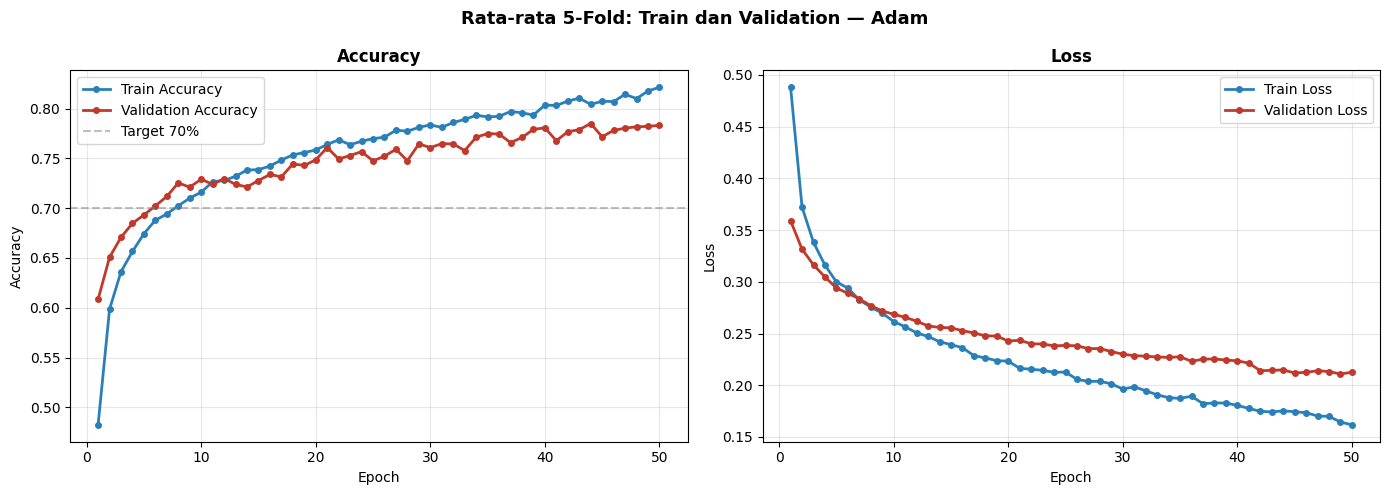

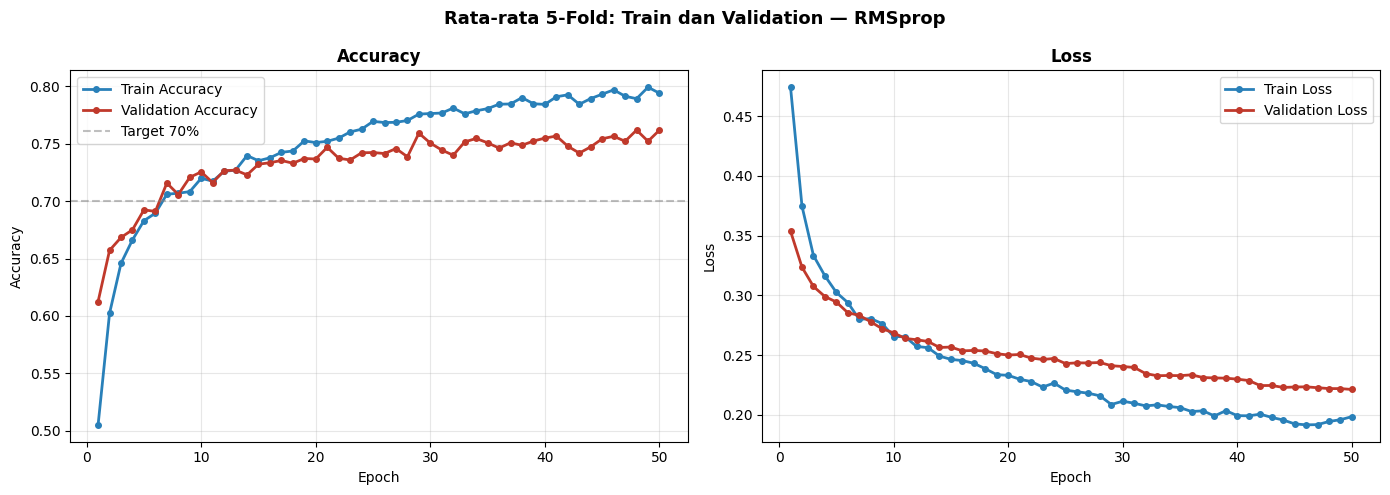

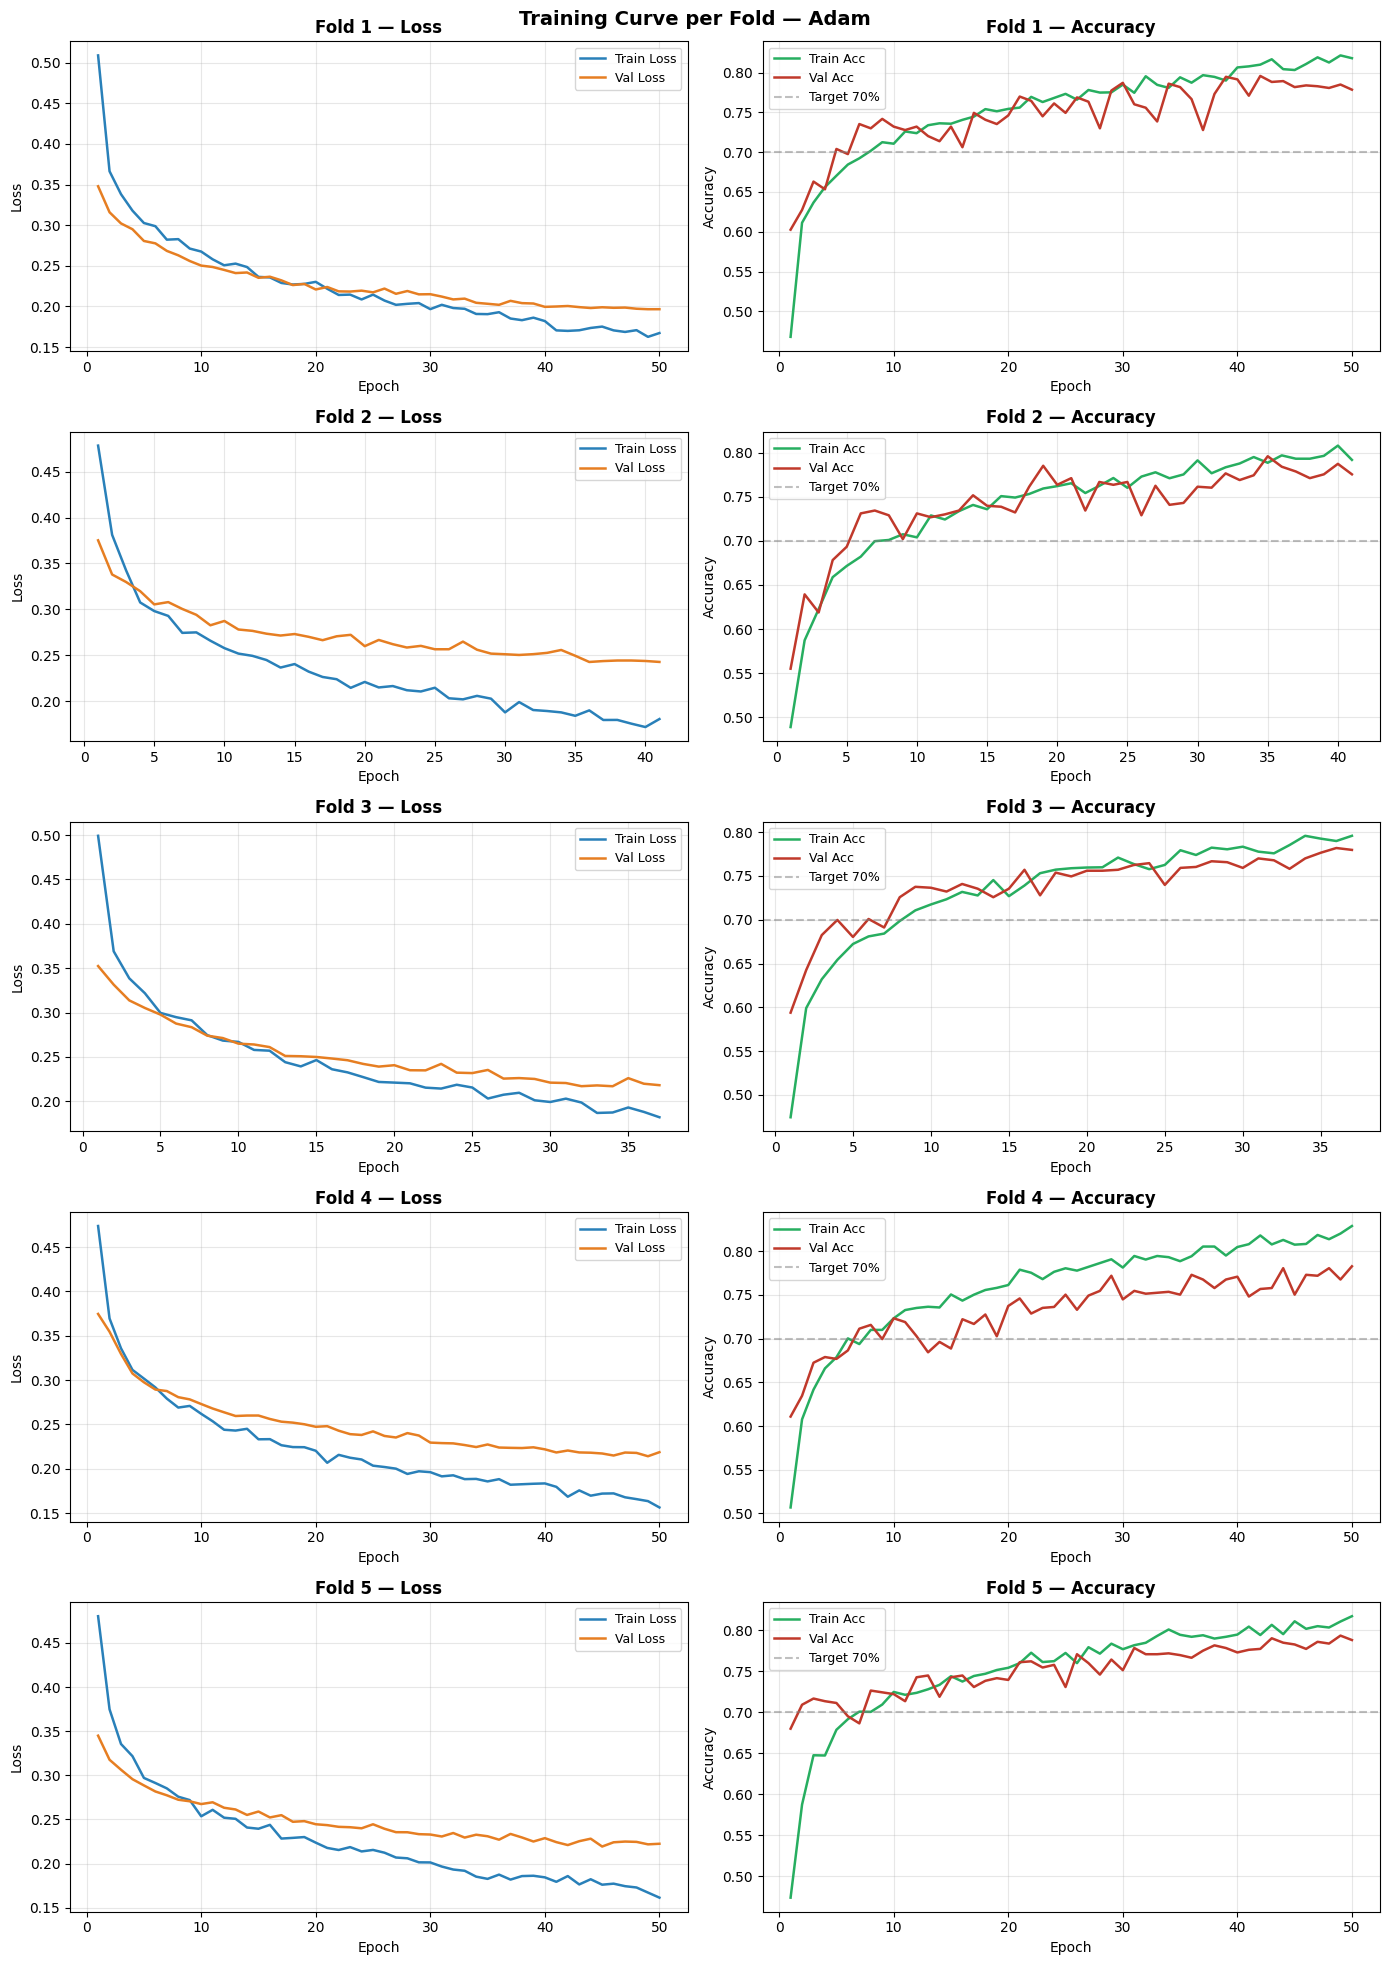

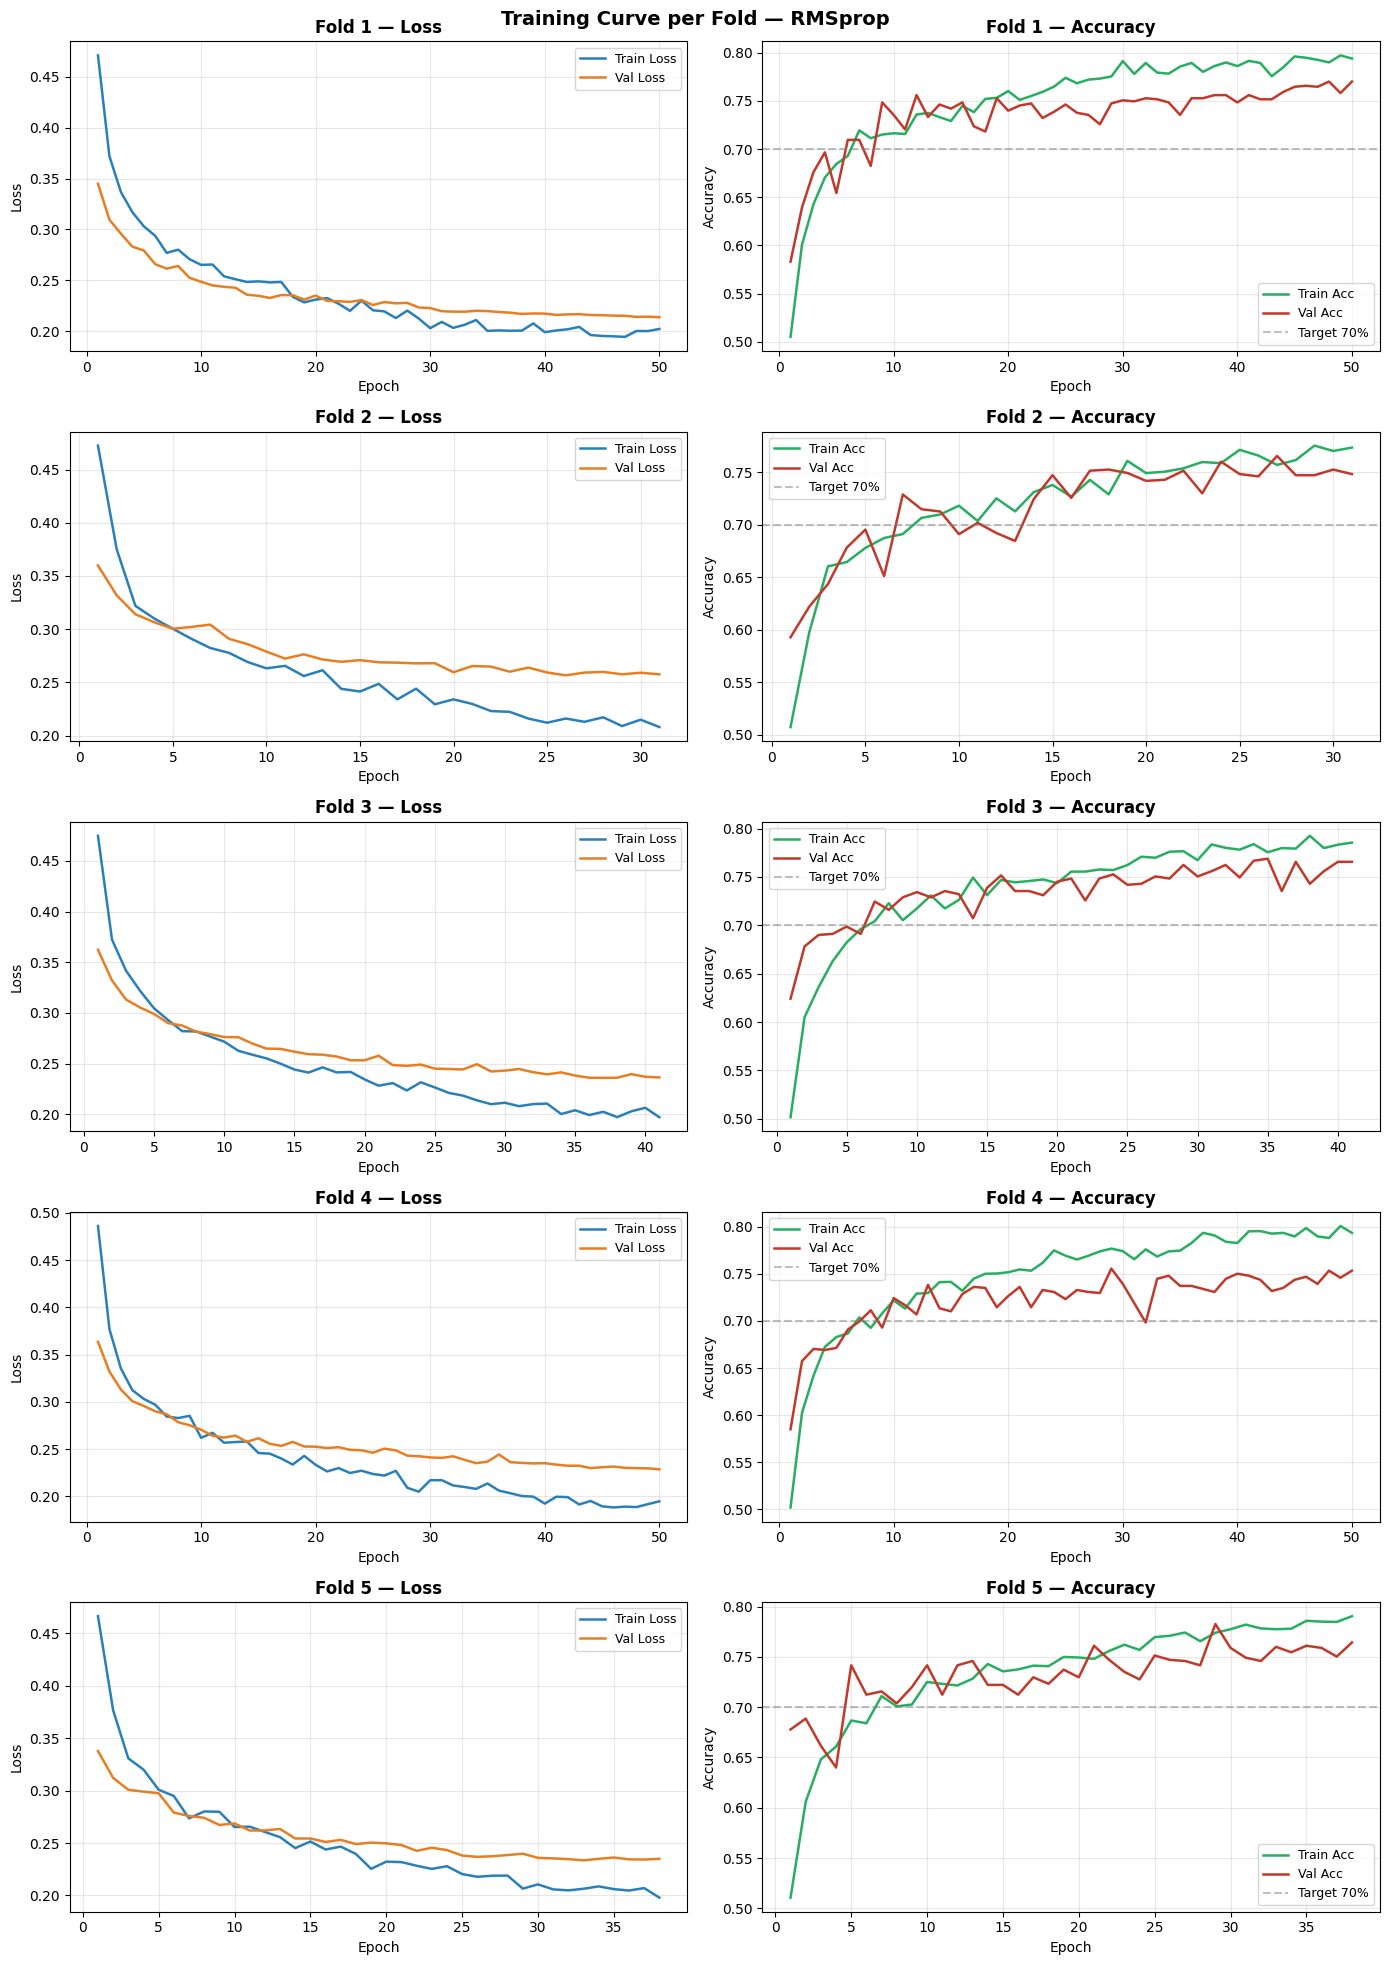

In [15]:
print("Hasil Perbandingan Optimizer")
print("=" * 50)

# Key history
ACC_KEY     = 'accuracy'
VAL_ACC_KEY = 'val_accuracy'

def hitung_macro_metrics(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    acc = accuracy_score(y_true, y_pred)

    prec_list, rec_list, f1_list = [], [], []
    for k in range(num_classes):
        TP = cm[k, k]
        FP = cm[:, k].sum() - TP
        FN = cm[k, :].sum() - TP
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0
        rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)

    return acc, float(np.mean(prec_list)), float(np.mean(rec_list)), float(np.mean(f1_list))

print("\nTabel Perbandingan Acc, Prec, Rec, dan Macro F1 per Fold:")
print("—" * 100)

metrics_per_opt = {
    nama_opt: {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    for nama_opt in daftar_optimizer
}

for nama_opt in daftar_optimizer:
    for fold in range(N_FOLDS):
        y_true_f = np.array(hasil[nama_opt]['y_true_fold'][fold])
        y_pred_f = np.array(hasil[nama_opt]['y_pred_fold'][fold])
        acc, macro_prec, macro_rec, macro_f1 = hitung_macro_metrics(
            y_true_f, y_pred_f, NUM_CLASSES
        )
        metrics_per_opt[nama_opt]['acc'].append(acc)
        metrics_per_opt[nama_opt]['prec'].append(macro_prec)
        metrics_per_opt[nama_opt]['rec'].append(macro_rec)
        metrics_per_opt[nama_opt]['f1'].append(macro_f1)

header = f"  {'Fold':<8}" + "".join(
    f"{n+' Acc':<12}{n+' Prec':<12}{n+' Rec':<12}{n+' F1':<12}"
    for n in daftar_optimizer
    )
print(header)
print("  " + "—" * 95)

for fold in range(N_FOLDS):
    baris = f"  Fold {fold+1:<3}"
    for nama_opt in daftar_optimizer:
        baris += f"{metrics_per_opt[nama_opt]['acc'][fold]:<12.4f}"
        baris += f"{metrics_per_opt[nama_opt]['prec'][fold]:<12.4f}"
        baris += f"{metrics_per_opt[nama_opt]['rec'][fold]:<12.4f}"
        baris += f"{metrics_per_opt[nama_opt]['f1'][fold]:<12.4f}"
    print(baris)
print("  " + "—" * 95)

baris_rata = f"  {'Rata':<8}"
for nama_opt in daftar_optimizer:
    baris_rata += f"{np.mean(metrics_per_opt[nama_opt]['acc']):<12.4f}"
    baris_rata += f"{np.mean(metrics_per_opt[nama_opt]['prec']):<12.4f}"
    baris_rata += f"{np.mean(metrics_per_opt[nama_opt]['rec']):<12.4f}"
    baris_rata += f"{np.mean(metrics_per_opt[nama_opt]['f1']):<12.4f}"
print(baris_rata)

# opt_terbaik dan rata_f1_per_opt sudah didefinisikan di cell training (cell 19)
print(f"\nOptimizer terbaik (rata-rata Accuracy): {opt_terbaik} ({rata_acc_per_opt[opt_terbaik]:.4f})")

# Helper
def pad_nan(lst, length):
    return lst + [np.nan] * (length - len(lst))


# Grafik 1 : Rata-rata Validation dan Loss 5-Fold
for nama_opt in daftar_optimizer:
    histories  = hasil[nama_opt]['history']
    max_epochs = max(len(h[ACC_KEY]) for h in histories)
    epochs     = np.arange(1, max_epochs + 1)

    mat_train_acc  = np.array([pad_nan(h[ACC_KEY],     max_epochs) for h in histories])
    mat_val_acc    = np.array([pad_nan(h[VAL_ACC_KEY], max_epochs) for h in histories])
    mat_train_loss = np.array([pad_nan(h['loss'],      max_epochs) for h in histories])
    mat_val_loss   = np.array([pad_nan(h['val_loss'],  max_epochs) for h in histories])

    mean_train_acc  = np.nanmean(mat_train_acc,  axis=0)
    mean_val_acc    = np.nanmean(mat_val_acc,    axis=0)
    mean_train_loss = np.nanmean(mat_train_loss, axis=0)
    mean_val_loss   = np.nanmean(mat_val_loss,   axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rata-rata 5-Fold: Train dan Validation — {nama_opt}',
                 fontsize=13, fontweight='bold')

    # Accuracy
    ax = axes[0]
    ax.plot(epochs, mean_train_acc, color='#2980b9', lw=2,
            marker='o', markersize=4, label='Train Accuracy')
    ax.plot(epochs, mean_val_acc,   color='#c0392b', lw=2,
            marker='o', markersize=4, label='Validation Accuracy')
    ax.axhline(0.7, color='gray', ls='--', alpha=0.5, label='Target 70%')
    ax.set_title('Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Loss
    ax = axes[1]
    ax.plot(epochs, mean_train_loss, color='#2980b9', lw=2,
            marker='o', markersize=4, label='Train Loss')
    ax.plot(epochs, mean_val_loss,   color='#c0392b', lw=2,
            marker='o', markersize=4, label='Validation Loss')
    ax.set_title('Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'avg_train_val_{nama_opt}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Grafik 2 : Training Curve per Fold 
for nama_opt in daftar_optimizer:
    histories = hasil[nama_opt]['history']

    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, 4 * N_FOLDS))
    fig.suptitle(f'Training Curve per Fold — {nama_opt}',
                 fontsize=14, fontweight='bold')

    for fold in range(N_FOLDS):
        h      = histories[fold]
        epochs = range(1, len(h['loss']) + 1)

        ax_loss = axes[fold, 0]
        ax_acc  = axes[fold, 1]

        ax_loss.plot(epochs, h['loss'],     color='#2980b9', lw=1.8, label='Train Loss')
        ax_loss.plot(epochs, h['val_loss'], color='#e67e22', lw=1.8, label='Val Loss')
        ax_loss.set_title(f'Fold {fold+1} — Loss', fontweight='bold')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(fontsize=9)
        ax_loss.grid(True, alpha=0.3)

        ax_acc.plot(epochs, h[ACC_KEY],     color='#27ae60', lw=1.8, label='Train Acc')
        ax_acc.plot(epochs, h[VAL_ACC_KEY], color='#c0392b', lw=1.8, label='Val Acc')
        ax_acc.axhline(0.7, color='gray', ls='--', alpha=0.5, label='Target 70%')
        ax_acc.set_title(f'Fold {fold+1} — Accuracy', fontweight='bold')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend(fontsize=9)
        ax_acc.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_curve_perfold_{nama_opt}.png', dpi=150, bbox_inches='tight')
    plt.show()

Confusion Matrix

OPTIMIZER: Adam

  Fold        TP     TN    FP    FN      Acc    Prec     Rec      F1
  —————————————————————————————————————————————————————————————————
  Fold 1     727   1653   199   199   0.7851  0.7404  0.7762  0.7504
  Fold 2     726   1652   200   200   0.7840  0.7325  0.7627  0.7408
  Fold 3     711   1637   215   215   0.7678  0.7289  0.7773  0.7361
  Fold 4     710   1635   215   215   0.7676  0.7200  0.7585  0.7276
  Fold 5     724   1649   201   201   0.7827  0.7325  0.7683  0.7416
  —————————————————————————————————————————————————————————————————
  Rata                                0.7774  0.7308   0.7686  0.7393


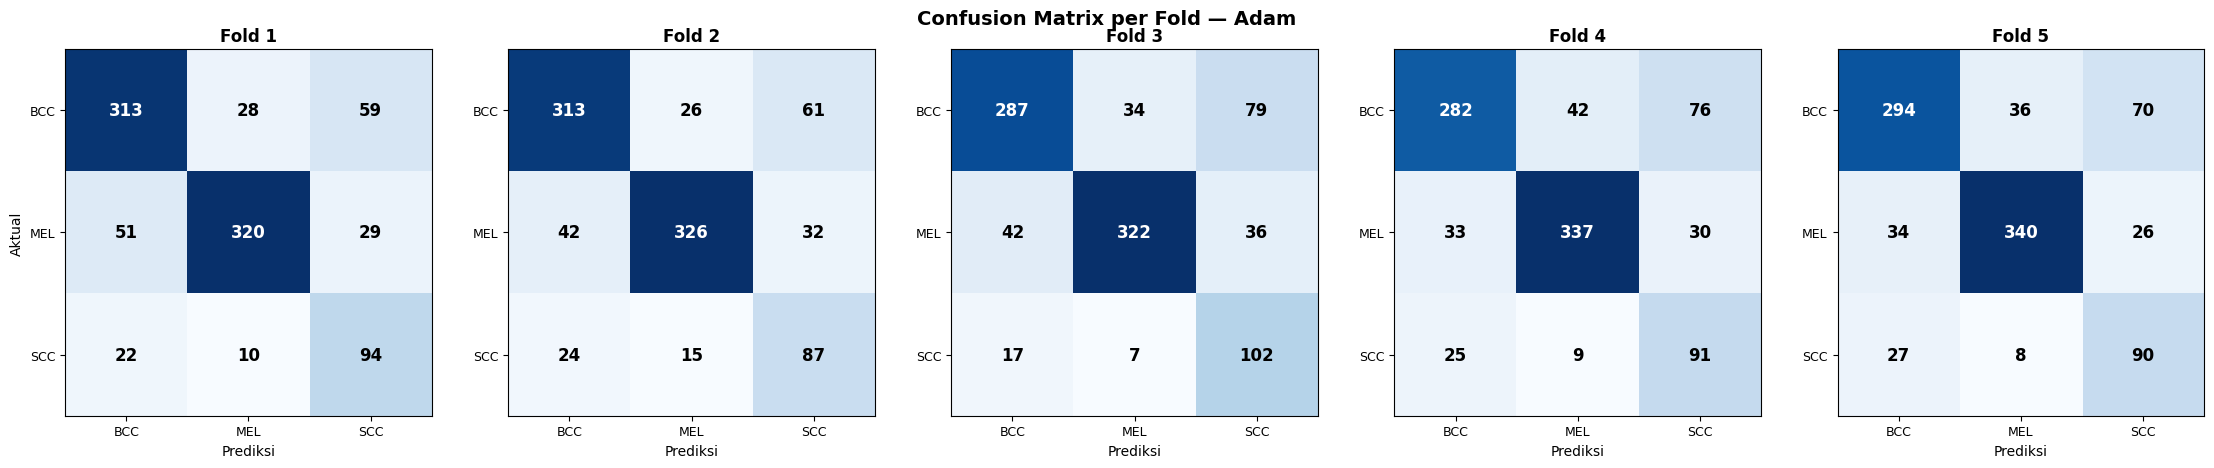


  --- Fold 1 ---
  Confusion Matrix 3x3 (Aktual \ Prediksi):
               BCC   MEL   SCC
         BCC   313    28    59
         MEL    51   320    29
         SCC    22    10    94

  Diketahui:
  Total TP = 313 + 320 + 94 = 727
  Total FP = 73 + 38 + 88 = 199
  Total FN = 87 + 80 + 32 = 199

  a. Accuracy = 727 / 926 = 0.7851

  b. Precision (per kelas):
     BCC: 313/(313+73) = 0.8109
     MEL: 320/(320+38) = 0.8939
     SCC: 94/(94+88) = 0.5165
     Macro Precision = 0.7404

  c. Recall (per kelas):
     BCC: 313/(313+87) = 0.7825
     MEL: 320/(320+80) = 0.8000
     SCC: 94/(94+32) = 0.7460
     Macro Recall = 0.7762

  d. F1-Score (per kelas):
     BCC: 2×(0.8109×0.7825)/(0.8109+0.7825) = 0.7964
     MEL: 2×(0.8939×0.8000)/(0.8939+0.8000) = 0.8443
     SCC: 2×(0.5165×0.7460)/(0.5165+0.7460) = 0.6104
     Macro F1-Score = 0.7504

  Hasil Fold 1: TP=727  TN=1653  FP=199  FN=199
  Acc=0.7851  Prec=0.7404  Rec=0.7762  F1=0.7504
  ——————————————————————————————————————————————————

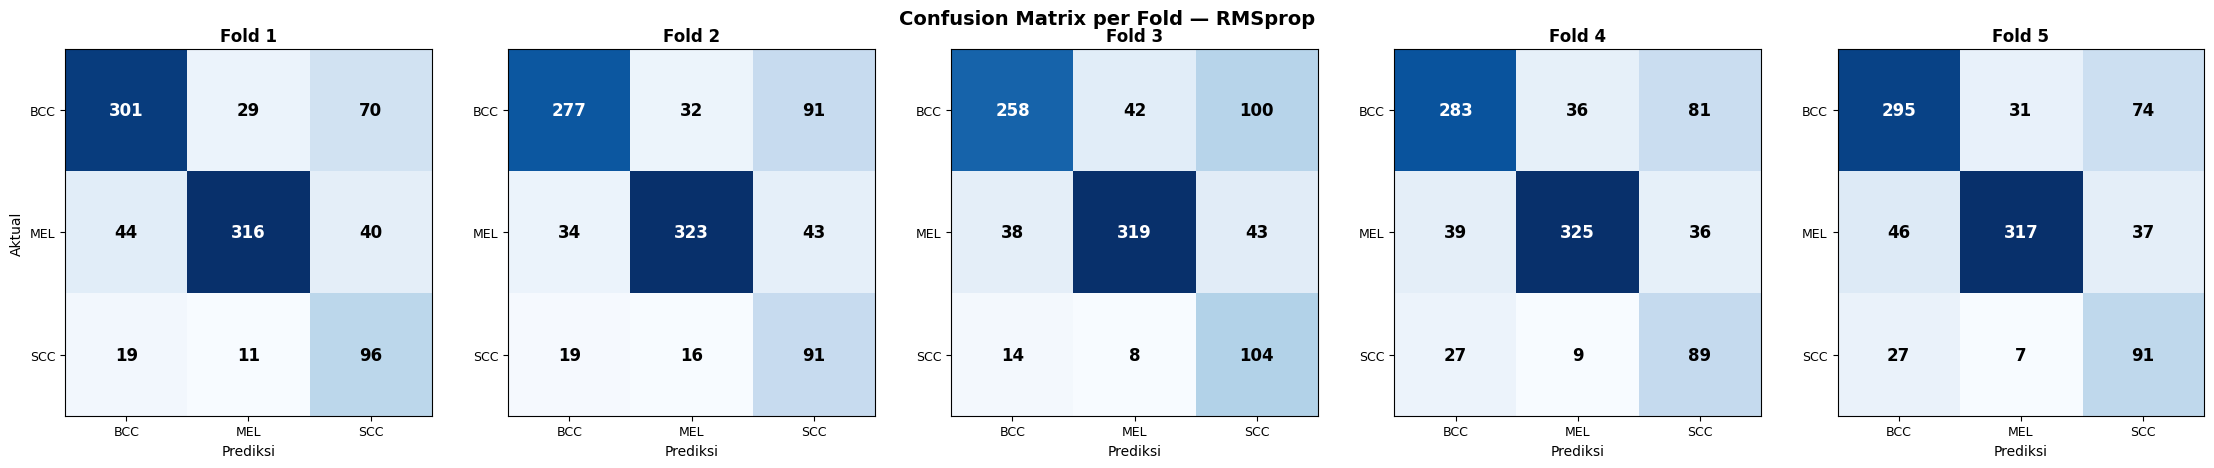


  --- Fold 1 ---
  Confusion Matrix 3x3 (Aktual \ Prediksi):
               BCC   MEL   SCC
         BCC   301    29    70
         MEL    44   316    40
         SCC    19    11    96

  Diketahui:
  Total TP = 301 + 316 + 96 = 713
  Total FP = 63 + 40 + 110 = 213
  Total FN = 99 + 84 + 30 = 213

  a. Accuracy = 713 / 926 = 0.7700

  b. Precision (per kelas):
     BCC: 301/(301+63) = 0.8269
     MEL: 316/(316+40) = 0.8876
     SCC: 96/(96+110) = 0.4660
     Macro Precision = 0.7269

  c. Recall (per kelas):
     BCC: 301/(301+99) = 0.7525
     MEL: 316/(316+84) = 0.7900
     SCC: 96/(96+30) = 0.7619
     Macro Recall = 0.7681

  d. F1-Score (per kelas):
     BCC: 2×(0.8269×0.7525)/(0.8269+0.7525) = 0.7880
     MEL: 2×(0.8876×0.7900)/(0.8876+0.7900) = 0.8360
     SCC: 2×(0.4660×0.7619)/(0.4660+0.7619) = 0.5783
     Macro F1-Score = 0.7341

  Hasil Fold 1: TP=713  TN=1639  FP=213  FN=213
  Acc=0.7700  Prec=0.7269  Rec=0.7681  F1=0.7341
  ————————————————————————————————————————————————

In [16]:
print("Confusion Matrix")
print("=" * 50)

nama_kelas_list = list(LabelEncode.classes_)

for nama_opt in daftar_optimizer:
    print(f"\n{'='*65}")
    print(f"OPTIMIZER: {nama_opt}")
    print(f"{'='*65}")

    # TABEL EVALUASI PER FOLD
    print(f"\n  {'Fold':<8} {'TP':>5} {'TN':>6} {'FP':>5} {'FN':>5}"
          f"  {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
    print("  " + "—" * 65)

    # Simpan untuk grafik & rata-rata
    fold_data = []

    for fold in range(N_FOLDS):
        y_true_f = np.array(hasil[nama_opt]['y_true_fold'][fold])
        y_pred_f = np.array(hasil[nama_opt]['y_pred_fold'][fold])
        cm = confusion_matrix(y_true_f, y_pred_f, labels=range(NUM_CLASSES))

        # Agregasi TP/TN/FP/FN (jumlah dari semua kelas)
        TP_agg, TN_agg, FP_agg, FN_agg = 0, 0, 0, 0
        prec_k, rec_k, f1_k = [], [], []

        for k in range(NUM_CLASSES):
            TP = cm[k, k]
            FP = cm[:, k].sum() - TP
            FN = cm[k, :].sum() - TP
            TN = cm.sum() - TP - FP - FN

            TP_agg += TP; TN_agg += TN
            FP_agg += FP; FN_agg += FN

            prec = TP / (TP + FP) if (TP + FP) > 0 else 0
            rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0
            prec_k.append(prec); rec_k.append(rec); f1_k.append(f1)

        # Macro average
        acc        = accuracy_score(y_true_f, y_pred_f)
        macro_prec = np.mean(prec_k)
        macro_rec  = np.mean(rec_k)
        macro_f1   = np.mean(f1_k)

        fold_data.append({
            'TP': TP_agg, 
            'TN': TN_agg, 
            'FP': FP_agg, 
            'FN': FN_agg,
            'acc': acc, 
            'prec': macro_prec, 
            'rec': macro_rec, 
            'f1': macro_f1,
            'cm': cm, 
            'y_true': y_true_f, 
            'y_pred': y_pred_f,
            'prec_per_kelas': prec_k, 
            'rec_per_kelas': rec_k, 
            'f1_per_kelas': f1_k,
        })

        print(f"  Fold {fold+1:<3} {TP_agg:>5} {TN_agg:>6} {FP_agg:>5} {FN_agg:>5}"
              f"  {acc:>7.4f} {macro_prec:>7.4f} {macro_rec:>7.4f} {macro_f1:>7.4f}")

    # Rata-rata
    print("  " + "—" * 65)
    print(f"  {'Rata':<8} {'':>5} {'':>6} {'':>5} {'':>5}"
          f"  {np.mean([d['acc'] for d in fold_data]):>7.4f}"
          f" {np.mean([d['prec'] for d in fold_data]):>7.4f}"
          f"  {np.mean([d['rec'] for d in fold_data]):>7.4f}"
          f" {np.mean([d['f1'] for d in fold_data]):>7.4f}")


    # CONFUSION MATRIX PER FOLD
    fig, axes = plt.subplots(1, N_FOLDS, figsize=(4.5 * N_FOLDS, 4.5))
    fig.suptitle(f'Confusion Matrix per Fold — {nama_opt}',
                 fontsize=14, fontweight='bold')

    for fold in range(N_FOLDS):
        cm = fold_data[fold]['cm']
        ax = axes[fold]

        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(f'Fold {fold+1}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prediksi')
        if fold == 0:
            ax.set_ylabel('Aktual')
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(nama_kelas_list, fontsize=9)
        ax.set_yticklabels(nama_kelas_list, fontsize=9)

        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if cm[i, j] > cm.max()/2 else 'black')

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_perfold_{nama_opt}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # DETAIL PERHITUNGAN PER KELAS PER FOLD
    for fold in range(N_FOLDS):
        d  = fold_data[fold]
        cm = d['cm']

        print(f"\n  --- Fold {fold+1} ---")
        print(f"  Confusion Matrix 3x3 (Aktual \\ Prediksi):")
        print(f"  {'':>10}" + "".join(f"{k:>6}" for k in nama_kelas_list))
        for i, k in enumerate(nama_kelas_list):
            print(f"  {k:>10}" + "".join(f"{cm[i,j]:>6}" for j in range(NUM_CLASSES)))

        print(f"\n  Diketahui:")
        print(f"  Total TP = " + " + ".join(f"{cm[k,k]}" for k in range(NUM_CLASSES))
              + f" = {d['TP']}")
        print(f"  Total FP = " + " + ".join(f"{cm[:,k].sum()-cm[k,k]}" for k in range(NUM_CLASSES))
              + f" = {d['FP']}")
        print(f"  Total FN = " + " + ".join(f"{cm[k,:].sum()-cm[k,k]}" for k in range(NUM_CLASSES))
              + f" = {d['FN']}")

        # Accuracy
        total = len(d['y_true'])
        print(f"\n  a. Accuracy = {d['TP']} / {total} = {d['acc']:.4f}")

        # Precision per kelas
        print(f"\n  b. Precision (per kelas):")
        for k in range(NUM_CLASSES):
            TP_k = cm[k, k]; FP_k = cm[:, k].sum() - TP_k
            print(f"     {nama_kelas_list[k]}: {TP_k}/({TP_k}+{FP_k})"
                  f" = {d['prec_per_kelas'][k]:.4f}")
        print(f"     Macro Precision = {d['prec']:.4f}")

        # Recall per kelas
        print(f"\n  c. Recall (per kelas):")
        for k in range(NUM_CLASSES):
            TP_k = cm[k, k]; FN_k = cm[k, :].sum() - TP_k
            print(f"     {nama_kelas_list[k]}: {TP_k}/({TP_k}+{FN_k})"
                  f" = {d['rec_per_kelas'][k]:.4f}")
        print(f"     Macro Recall = {d['rec']:.4f}")

        # F1-Score per kelas
        print(f"\n  d. F1-Score (per kelas):")
        for k in range(NUM_CLASSES):
            p = d['prec_per_kelas'][k]; r = d['rec_per_kelas'][k]
            print(f"     {nama_kelas_list[k]}: 2×({p:.4f}×{r:.4f})"
                  f"/({p:.4f}+{r:.4f}) = {d['f1_per_kelas'][k]:.4f}")
        print(f"     Macro F1-Score = {d['f1']:.4f}")

        print(f"\n  Hasil Fold {fold+1}: TP={d['TP']}  TN={d['TN']}"
              f"  FP={d['FP']}  FN={d['FN']}")
        print(f"  Acc={d['acc']:.4f}  Prec={d['prec']:.4f}"
              f"  Rec={d['rec']:.4f}  F1={d['f1']:.4f}")
        print("  " + "—" * 55)


<div style="
    padding-left: 18px;
    border-left: 4px solid #111827;
    margin-top: 25px;
">
    
<h3 style="
    margin-bottom: 8px;
    font-size: 24px;
    font-weight: 600;
"> Tahap 8 - Grad-Cam 
</h3>

<p style="
    margin-top: 0;
    color: #555;
    line-height: 1.7;
">Visualisasi Model dengan Grad-cam</p> 

</div>

In [17]:
print("GRAD-CAM")
print("=" * 50)

# Load model terbaik dari optimizer terbaik
model_terbaik = tf.keras.models.load_model(
    f'/kaggle/working/model_terbaik_efficientnet_partial_LR2{opt_terbaik}.keras',
     custom_objects={'focal_loss_function': focal_loss_function}
)
print(f"Model '{opt_terbaik}' berhasil di-load!")
print(f"Info: {best_model_info_per_opt[opt_terbaik]}")

#Fungsi Gradcam
def buat_gradcam(model, gambar, indeks_kelas):

    # 1. Buat grad_model: input[conv_output, prediksi]
    grad_model = tf.keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(GRADCAM_LAYER).output, model.output]
    )

    # 2. Forward pass dan rekam gradient
    with tf.GradientTape() as tape:
        inp              = tf.cast(gambar, tf.float32)
        conv_out, preds  = grad_model(inp, training=False)
        skor_kelas       = preds[:, indeks_kelas]

    # 3. Hitung gradient
    grads = tape.gradient(skor_kelas, conv_out)

    if grads is None:
        print(f"Tolong cek kembali nama layer '{GRADCAM_LAYER}'")
        return np.zeros((IMG_SIZE, IMG_SIZE))

    # 4. Buat heatmap
    bobot   = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_out[0] * bobot, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return cv2.resize(heatmap.numpy(), (IMG_SIZE, IMG_SIZE))

GRAD-CAM
Model 'Adam' berhasil di-load!
Info: {'optimizer': 'Adam', 'fold': 1, 'val_acc': 0.785097192224622, 'val_macro_f1': 0.7503848154012306}


——————————————————————————————————————————————————
Menampilkan Grad-CAM (3 gambar per kelas)
——————————————————————————————————————————————————


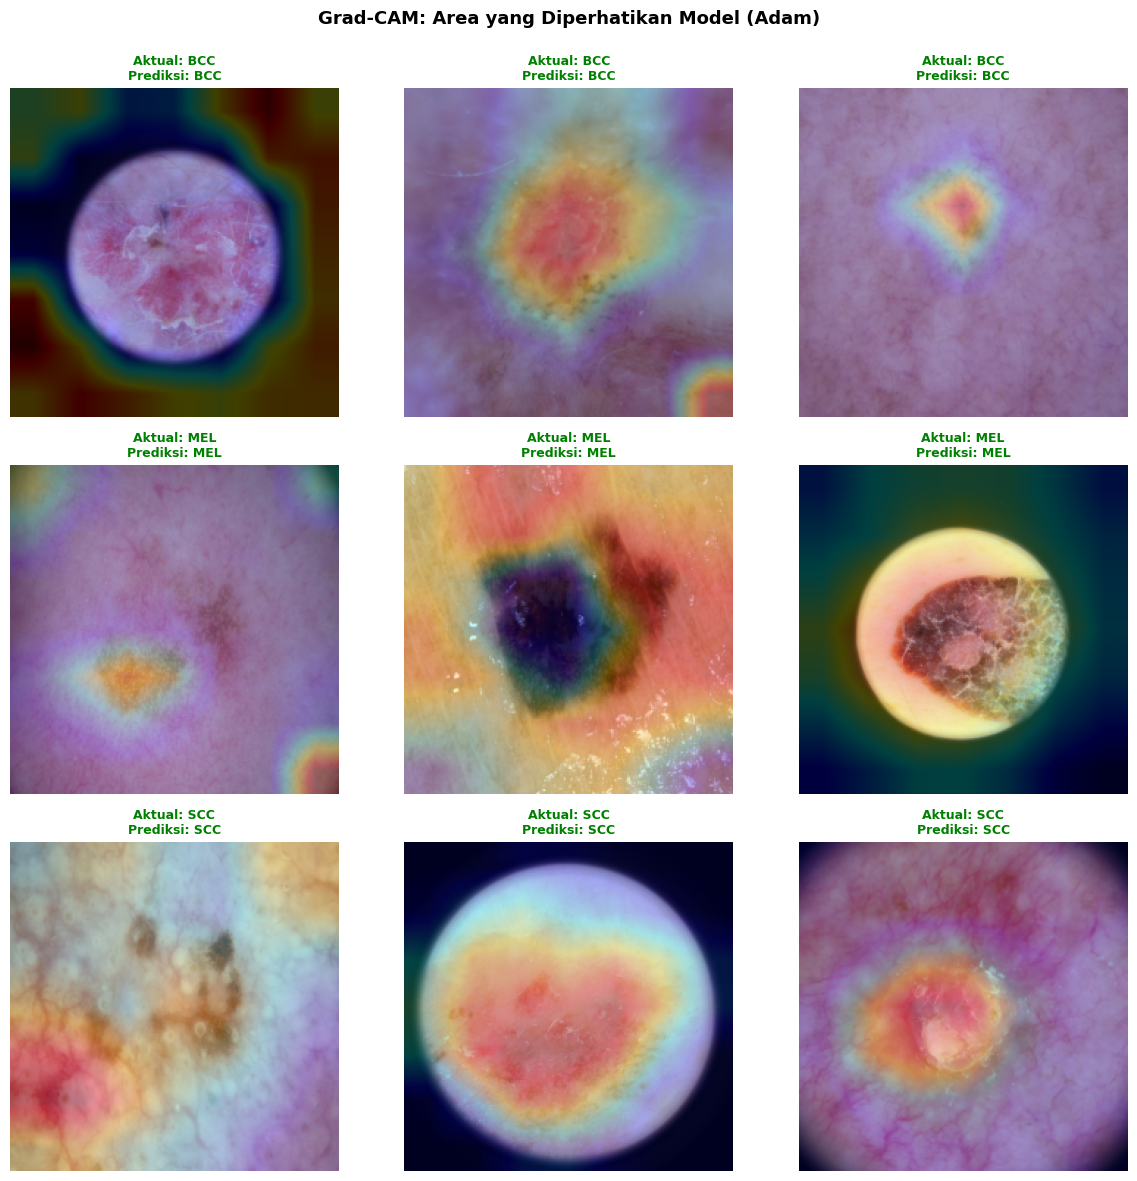

In [18]:
def tampilkan_gradcam(gambar_display, heatmap, label_asli, label_prediksi, ax):
    heatmap_u8    = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

    overlay = gambar_display * 0.75 + heatmap_color * 0.25
    overlay = np.clip(overlay, 0, 1)

    ax.imshow(overlay)
    warna = 'green' if label_asli == label_prediksi else 'red'
    ax.set_title(f'Aktual: {label_asli}\nPrediksi: {label_prediksi}',
                 fontsize=9, color=warna, fontweight='bold')
    ax.axis('off')

print("—" * 50)
print("Menampilkan Grad-CAM (3 gambar per kelas)")
print("—" * 50)

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, 4 * NUM_CLASSES))
fig.suptitle(
    f'Grad-CAM: Area yang Diperhatikan Model ({opt_terbaik})\n',
    fontsize=13, fontweight='bold'
)

for kelas_idx in range(NUM_CLASSES):
    nama_kelas = LabelEncode.classes_[kelas_idx]
    idx_kelas  = np.where(y_encoded == kelas_idx)[0]

    # Prioritas: ambil 3 sampel yang prediksinya BENAR
    sampel = []
    for idx in idx_kelas:
        if len(sampel) >= 3:
            break
        inp  = preprocess_input(X[idx:idx+1].astype(np.float32))
        pred = np.argmax(model_terbaik.predict(inp, verbose=0)[0])
        if pred == kelas_idx:
            sampel.append(idx)

    # Fallback kalau prediksi benar < 3
    if len(sampel) < 3:
        sisa   = [i for i in idx_kelas if i not in sampel]
        sampel += list(sisa[:3 - len(sampel)])

    for col, idx in enumerate(sampel[:3]):
        gambar_model  = preprocess_input(X[idx:idx+1].astype(np.float32))
        gambar_tampil = X[idx].astype(np.float32) / 255.0
        pred_proba    = model_terbaik.predict(gambar_model, verbose=0)
        pred_kelas    = np.argmax(pred_proba[0])
        nama_pred     = LabelEncode.classes_[pred_kelas]

        heatmap = buat_gradcam(model_terbaik, gambar_model, pred_kelas)
        tampilkan_gradcam(gambar_tampil, heatmap, nama_kelas,
                          nama_pred, axes[kelas_idx, col])

    axes[kelas_idx, 0].set_ylabel(nama_kelas, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('gradcam_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

Grad-CAM: Prediksi Benar vs Salah (Semua Kelas)


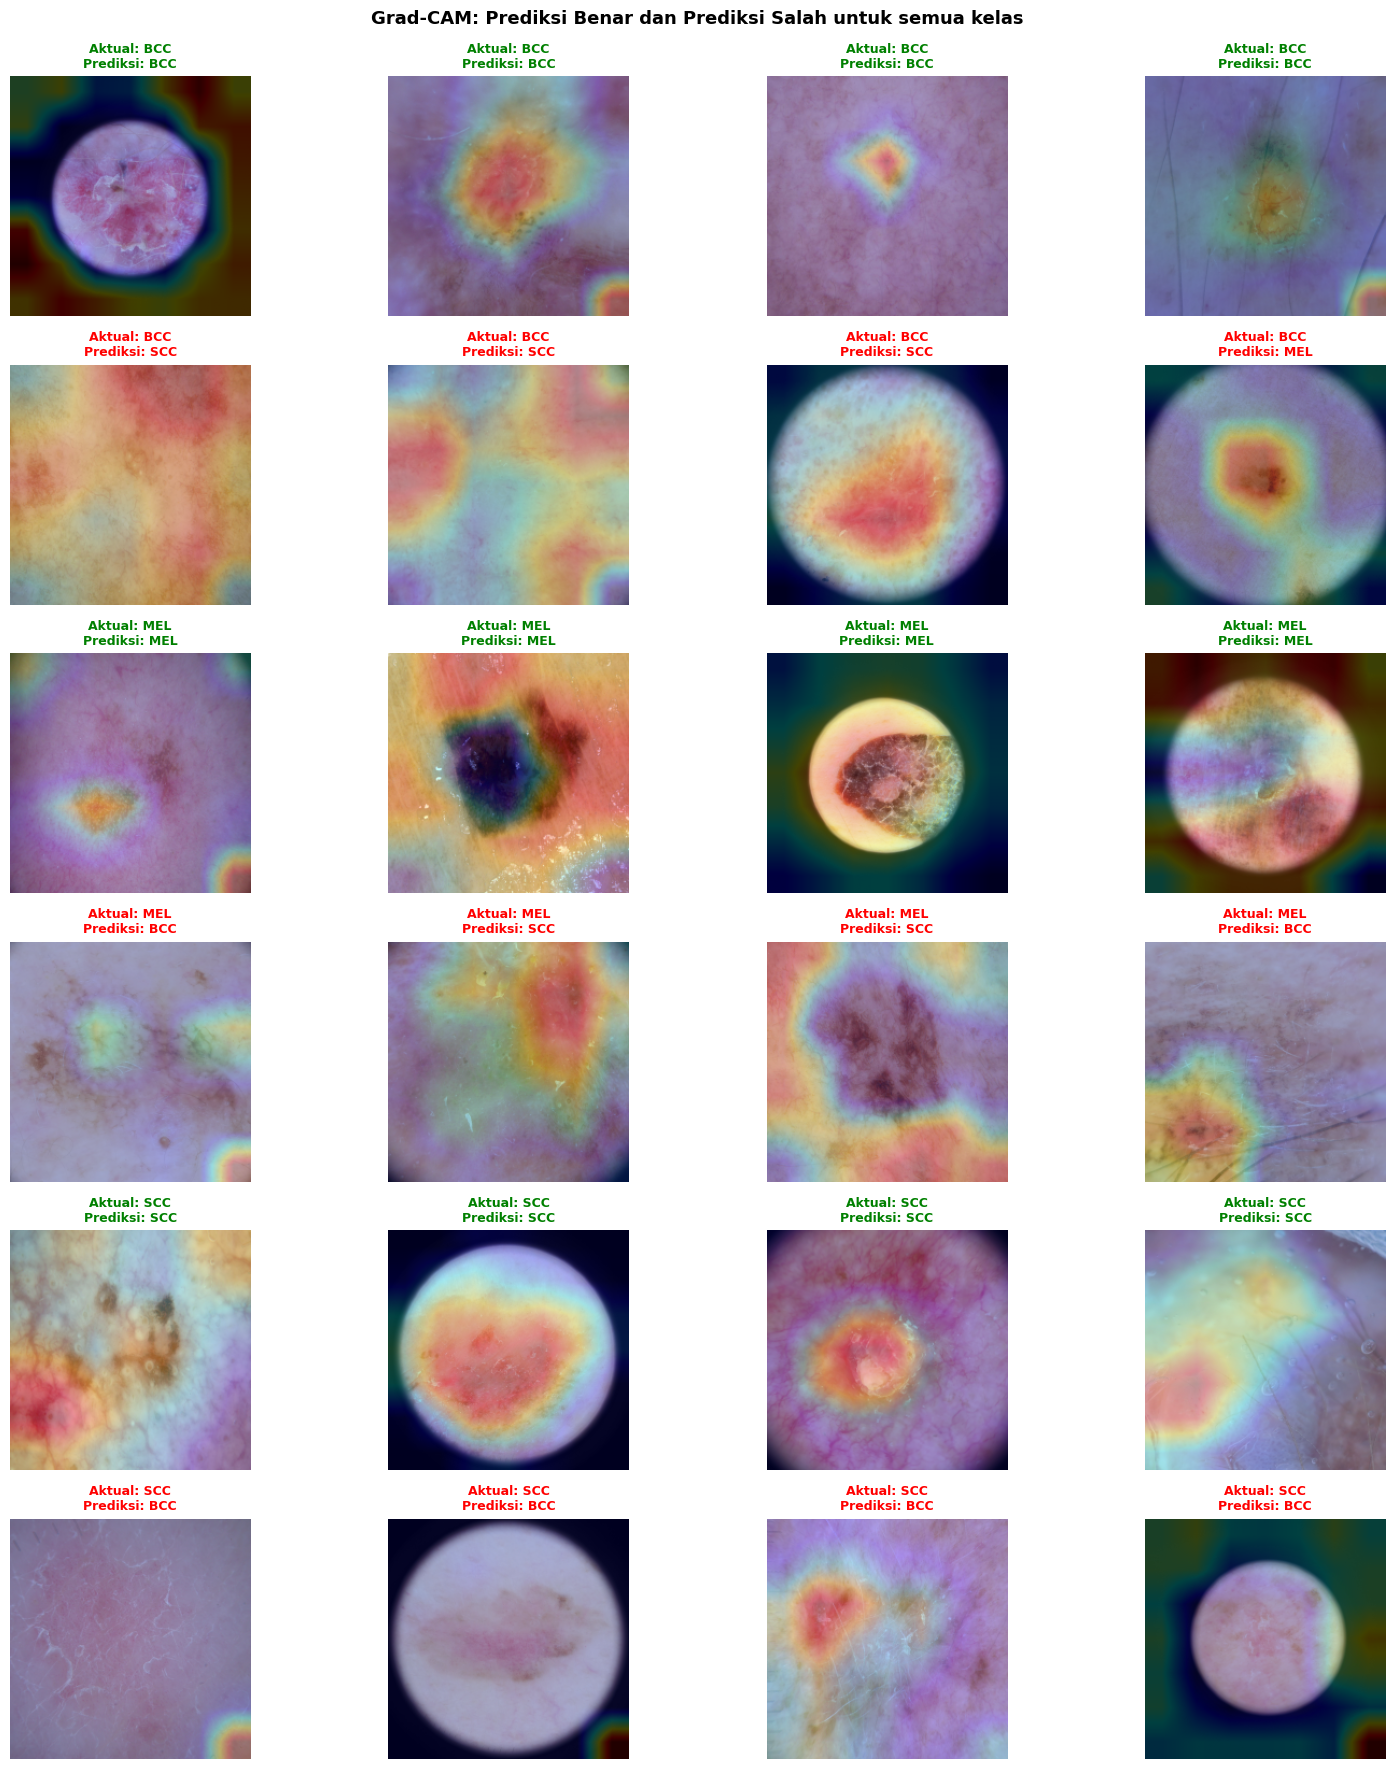

In [19]:
print("Grad-CAM: Prediksi Benar vs Salah (Semua Kelas)")
print("=" * 50)

fig, axes = plt.subplots(NUM_CLASSES * 2, 4, figsize=(16, 6 * NUM_CLASSES))
fig.suptitle('Grad-CAM: Prediksi Benar dan Prediksi Salah untuk semua kelas\n',
    fontsize=13, fontweight='bold'
)

for kelas_idx in range(NUM_CLASSES):
    nama_kelas               = LabelEncode.classes_[kelas_idx]
    benar_list, salah_list   = [], []

    # Kumpulkan 4 sampel benar dan 4 sampel salah untuk kelas ini
    for idx in np.where(y_encoded == kelas_idx)[0]:
        if len(benar_list) >= 4 and len(salah_list) >= 4:
            break
        inp        = preprocess_input(X[idx:idx+1].astype(np.float32))
        pred_kelas = np.argmax(model_terbaik.predict(inp, verbose=0)[0])

        if pred_kelas == kelas_idx and len(benar_list) < 4:
            benar_list.append((idx, pred_kelas))
        elif pred_kelas != kelas_idx and len(salah_list) < 4:
            salah_list.append((idx, pred_kelas))

    # Baris atas = benar, baris bawah = salah
    baris_benar = kelas_idx * 2
    baris_salah = kelas_idx * 2 + 1

    # Label baris di kolom pertama
    axes[baris_benar, 0].set_ylabel(f'{nama_kelas}\nBenar', fontsize=10, fontweight='bold')
    axes[baris_salah, 0].set_ylabel(f'{nama_kelas}\nSalah', fontsize=10, fontweight='bold')

    for col in range(4):
        # Baris Benar
        if col < len(benar_list):
            idx, pred_kelas   = benar_list[col]
            gambar_model      = preprocess_input(X[idx:idx+1].astype(np.float32))
            gambar_tampil     = X[idx].astype(np.float32) / 255.0
            nama_pred         = LabelEncode.classes_[pred_kelas]
            heatmap           = buat_gradcam(model_terbaik, gambar_model, pred_kelas)
            tampilkan_gradcam(gambar_tampil, heatmap, nama_kelas, nama_pred, axes[baris_benar, col])
        else:
            axes[baris_benar, col].axis('off')  # kosong kalau sampel kurang dari 4

        # Baris Salah
        if col < len(salah_list):
            idx, pred_kelas   = salah_list[col]
            gambar_model      = preprocess_input(X[idx:idx+1].astype(np.float32))
            gambar_tampil     = X[idx].astype(np.float32) / 255.0
            nama_pred         = LabelEncode.classes_[pred_kelas]
            heatmap           = buat_gradcam(model_terbaik, gambar_model, pred_kelas)
            tampilkan_gradcam(gambar_tampil, heatmap, nama_kelas, nama_pred, axes[baris_salah, col])
        else:
            axes[baris_salah, col].axis('off')  # kosong kalau sampel kurang dari 4

plt.tight_layout()
plt.savefig('gradcam_benar_vs_salah.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print("Simpan Hasil")
print("=" * 50)

# Simpan hasil training (backup numpy)
np.save('/kaggle/working/hasil_training_efficientnet_LR2_partial.npy', hasil)

nama_kelas_list = list(LabelEncode.classes_)


# FUNGSI: Hitung metrik per fold (format tabel)
def hitung_metrik_perfold(y_true_fold, y_pred_fold, num_classes):
    rows_summary = []
    nama_kelas   = list(LabelEncode.classes_)

    for fold_idx, (yt, yp) in enumerate(zip(y_true_fold, y_pred_fold)):
        yt = np.array(yt)
        yp = np.array(yp)
        cm = confusion_matrix(yt, yp, labels=list(range(num_classes)))

        acc = accuracy_score(yt, yp)

        TP_agg, TN_agg, FP_agg, FN_agg = 0, 0, 0, 0
        prec_list, rec_list, f1_list = [], [], []

        for k in range(num_classes):
            TP = cm[k, k]
            FP = cm[:, k].sum() - TP
            FN = cm[k, :].sum() - TP
            TN = cm.sum() - TP - FP - FN

            TP_agg += TP; TN_agg += TN
            FP_agg += FP; FN_agg += FN

            prec = TP / (TP + FP) if (TP + FP) > 0 else 0
            rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0

            prec_list.append(prec)
            rec_list.append(rec)
            f1_list.append(f1)

        rows_summary.append({
            'Fold'              : f'Fold {fold_idx + 1}',
            'TP'                : int(TP_agg),
            'TN'                : int(TN_agg),
            'FP'                : int(FP_agg),
            'FN'                : int(FN_agg),
            'Accuracy'          : round(acc, 4),
            'Precision (Macro)' : round(np.mean(prec_list), 4),
            'Recall (Macro)'    : round(np.mean(rec_list), 4),
            'F1-Score (Macro)'  : round(np.mean(f1_list), 4),
        })

    df_summary = pd.DataFrame(rows_summary)

    # Baris rata-rata
    cols_numerik = [c for c in df_summary.columns if c not in ['Fold','TP','TN','FP','FN']]
    rata = {'Fold': 'Rata-Rata', 'TP': '', 'TN': '', 'FP': '', 'FN': ''}
    for col in cols_numerik:
        rata[col] = round(df_summary[col].mean(), 4)
    df_summary = pd.concat([df_summary, pd.DataFrame([rata])], ignore_index=True)

    return df_summary


# Sheet 1: Akurasi & Macro F1 per Fold
data_akurasi = {}
for nama_opt in daftar_optimizer:
    data_akurasi[f'{nama_opt} Acc']      = hasil[nama_opt]['val_acc']
    data_akurasi[f'{nama_opt} Macro F1'] = hasil[nama_opt]['val_macro_f1']

df_akurasi = pd.DataFrame(data_akurasi)
df_akurasi.index = [f'Fold {i+1}' for i in range(N_FOLDS)]
rata_row = {}
for col in df_akurasi.columns:
    rata_row[col] = df_akurasi[col].mean()
df_akurasi.loc['Rata-rata'] = rata_row


# Sheet 2-3: Evaluasi per Fold (TP/TN/FP/FN + metrik macro)
df_eval_fold = {}
for nama_opt in daftar_optimizer:
    df_eval_fold[nama_opt] = hitung_metrik_perfold(
        hasil[nama_opt]['y_true_fold'],
        hasil[nama_opt]['y_pred_fold'],
        NUM_CLASSES
    )

# Simpan ke Excel
path_excel = '/kaggle/working/hasil_efficientnet_LR2_partial.xlsx'

with pd.ExcelWriter(path_excel, engine='openpyxl') as writer:
    # Sheet 1: Akurasi & Macro F1 per Fold
    df_akurasi.to_excel(writer, sheet_name='Akurasi dan F1 per Fold')

    # Sheet 2-3: Evaluasi per Fold (format seperti laporan)
    for nama_opt in daftar_optimizer:
        df_eval_fold[nama_opt].to_excel(
            writer,
            sheet_name=f'Evaluasi Fold {nama_opt}',
            index=False
        )


# Rekap Akhir
print("REKAP AKHIR")
print(" ")
print(f"Model      : EfficientNet-B2 (Transfer Learning)")
print(f"Validation : Stratified {N_FOLDS}-Fold Cross Validation")
print(f"Optimizer  : {daftar_optimizer}")

print( )
print(f"Hasil Rata-Rata per Optimizer:")
for nama_opt in daftar_optimizer:
    rata_acc = np.mean(hasil[nama_opt]['val_acc'])
    rata_f1  = np.mean(hasil[nama_opt]['val_macro_f1'])
    print(f"{nama_opt:<10}: Acc={rata_acc:.4f} | Macro F1={rata_f1:.4f}")

info_opt = best_model_info_per_opt[opt_terbaik]
print(" ")
print(f"Optimizer Terbaik (rata-rata Accuracy)")
print(f"Optimizer           : {opt_terbaik}")
print(f"Rata-rata Accuracy  : {rata_acc_per_opt[opt_terbaik]:.4f}")

print(" ")
print(f"Model yang Disimpan (fold dengan Accuracy tertinggi dari {opt_terbaik}):")
print(f"Fold               : {info_opt['fold']}")
print(f"Macro F1           : {info_opt['val_macro_f1']:.4f}")
print(f"Accuracy           : {info_opt['val_acc']:.4f}")
print(f"Training dan Evaluasi Model Selesai")

Simpan Hasil
REKAP AKHIR
 
Model      : EfficientNet-B2 (Transfer Learning)
Validation : Stratified 5-Fold Cross Validation
Optimizer  : ['Adam', 'RMSprop']

Hasil Rata-Rata per Optimizer:
Adam      : Acc=0.7774 | Macro F1=0.7393
RMSprop   : Acc=0.7530 | Macro F1=0.7156
 
Optimizer Terbaik (rata-rata Accuracy)
Optimizer           : Adam
Rata-rata Accuracy  : 0.7774
 
Model yang Disimpan (fold dengan Accuracy tertinggi dari Adam):
Fold               : 1
Macro F1           : 0.7504
Accuracy           : 0.7851
Training dan Evaluasi Model Selesai
